# Sistema de Rutas Aéreas EcoVuelo

## Unidad 4: Estructuras de Datos No Lineales

### Tema 1: Grafos

**Región seleccionada:** Sierra central del Ecuador

**Ciudades:** Latacunga, Salcedo, Ambato, Baños, Riobamba y Guaranda.

**Tipo de grafo:** No dirigido y ponderado.

**Peso de las rutas:** Distancia aproximada en kilómetros.


In [ ]:
# Librerías necesarias para trabajar con grafos y dibujarlos

import networkx as nx
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [ ]:
# Creación de un grafo no dirigido

grafo = nx.Graph()

# Ciudades seleccionadas para el proyecto

ciudades = [
    "Latacunga",
    "Salcedo",
    "Ambato",
    "Baños",
    "Riobamba",
    "Guaranda"
]

# Agregar todas las ciudades al grafo

grafo.add_nodes_from(ciudades)

# Mostrar las ciudades registradas

print("Ciudades registradas en EcoVuelo:")

for ciudad in grafo.nodes:
    print("-", ciudad)

print("\nTotal de ciudades:", grafo.number_of_nodes())

Ciudades registradas en EcoVuelo:
- Latacunga
- Salcedo
- Ambato
- Baños
- Riobamba
- Guaranda

Total de ciudades: 6


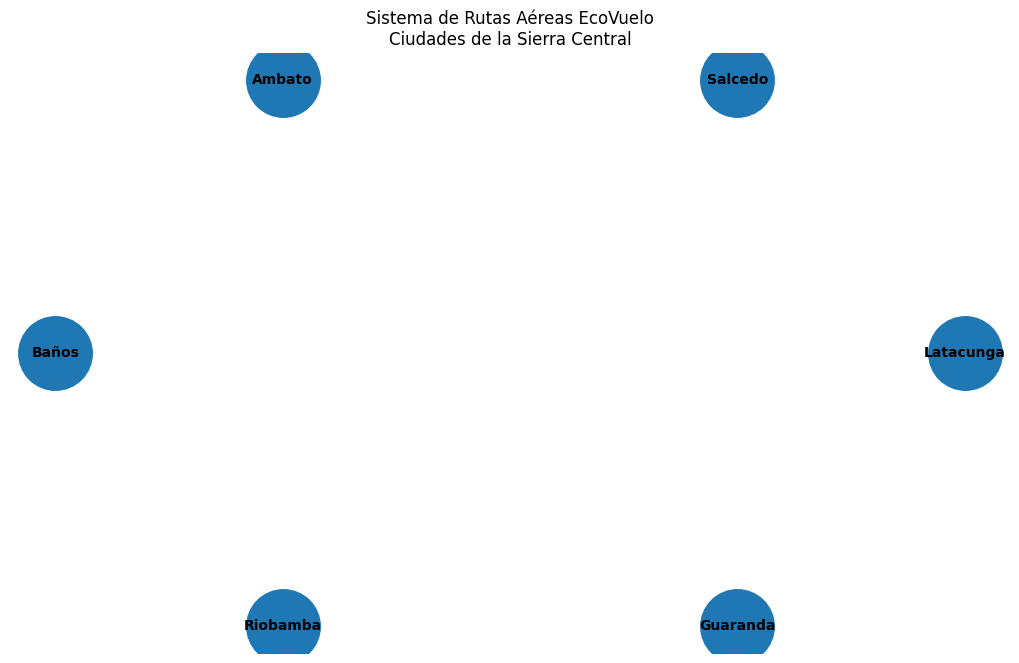

In [ ]:
# Visualización inicial de las ciudades

plt.figure(figsize=(10, 6))

posiciones = nx.circular_layout(grafo)

nx.draw(
    grafo,
    posiciones,
    with_labels=True,
    node_size=2800,
    font_size=10,
    font_weight="bold"
)

plt.title("Sistema de Rutas Aéreas EcoVuelo\nCiudades de la Sierra Central")
plt.axis("off")
plt.show()

## Descripción general de la primera etapa

En la primera etapa del proyecto se creó la estructura inicial del Sistema de Rutas Aéreas EcoVuelo utilizando el lenguaje de programación Python dentro de Google Colab.

Para representar la red de transporte se seleccionó un grafo no dirigido y ponderado. Se considera no dirigido porque las conexiones registradas podrán recorrerse en ambos sentidos; es decir, una ruta entre dos ciudades permitirá representar tanto el trayecto de ida como el de regreso. El grafo será ponderado porque cada ruta almacenará una distancia expresada en kilómetros.

La región geográfica seleccionada es la Sierra Central del Ecuador. Las seis ciudades que forman parte de la red son Latacunga, Salcedo, Ambato, Baños de Agua Santa, Riobamba y Guaranda.

Dentro del grafo, cada ciudad representa un nodo o vértice. Para crear y administrar esta estructura se utiliza la librería NetworkX, mientras que Matplotlib permite generar una representación gráfica de la red.

Inicialmente se creó un grafo vacío mediante NetworkX. Después se registró una lista con las seis ciudades seleccionadas y se agregaron todas como nodos. El programa mostró los nombres de las ciudades y comprobó que el número total de vértices registrados fuera igual a seis.

Finalmente, se realizó una primera visualización en la que las ciudades aparecieron separadas y sin conexiones. Esto ocurrió porque en esa etapa todavía no se habían añadido las rutas. La finalidad de la representación inicial fue verificar que todos los nodos estuvieran creados correctamente antes de comenzar la construcción de la red ponderada.


## Segunda etapa: creación de las rutas ponderadas

En esta etapa se construirán las conexiones iniciales del Sistema de Rutas Aéreas EcoVuelo. Las seis ciudades ya registradas se relacionarán mediante rutas directas, las cuales estarán representadas por las aristas del grafo.

Como el proyecto utiliza un grafo ponderado, cada ruta tendrá un peso numérico. En este caso, el peso representará la distancia por carretera, expresada en kilómetros, entre las dos ciudades conectadas.

Para mantener datos uniformes y verificables, se adoptará un valor fijo para cada conexión, tomado de un mismo planificador de rutas. Las distancias conservarán un decimal y no serán redondeadas. De esta manera, cada ruta tendrá un peso claramente definido dentro del sistema.

Se registrarán ocho rutas iniciales. Esta cantidad permitirá que las seis ciudades permanezcan comunicadas y que existan diferentes alternativas para recorrer la red. La ciudad de Ambato funcionará como uno de los puntos principales de conexión, debido a que se relacionará directamente con varias ciudades.

La estructura creada en esta etapa permitirá posteriormente buscar rutas, consultar distancias, mostrar destinos directos, calcular el grado de conectividad de una ciudad y ejecutar los algoritmos de recorrido BFS y DFS.

In [ ]:
# Rutas iniciales del Sistema EcoVuelo
# Cada tupla contiene:
# ciudad de origen, ciudad de destino y distancia en kilómetros

rutas = [
    ("Latacunga", "Salcedo", 13.3),
    ("Latacunga", "Ambato", 39.8),
    ("Salcedo", "Ambato", 27.9),
    ("Ambato", "Baños", 38.4),
    ("Ambato", "Riobamba", 58.3),
    ("Baños", "Riobamba", 54.2),
    ("Riobamba", "Guaranda", 57.2),
    ("Ambato", "Guaranda", 91.9)
]

# Agregar las rutas y sus respectivos pesos al grafo

grafo.add_weighted_edges_from(rutas)

# Mostrar las rutas registradas

print("Rutas registradas en el Sistema EcoVuelo:\n")

for origen, destino, datos in grafo.edges(data=True):
    distancia = datos["weight"]
    print(f"- {origen} ↔ {destino}: {distancia:.1f} km")

# Mostrar la cantidad total de rutas

print("\nTotal de rutas registradas:", grafo.number_of_edges())

Rutas registradas en el Sistema EcoVuelo:

- Latacunga ↔ Salcedo: 13.3 km
- Latacunga ↔ Ambato: 39.8 km
- Salcedo ↔ Ambato: 27.9 km
- Ambato ↔ Baños: 38.4 km
- Ambato ↔ Riobamba: 58.3 km
- Ambato ↔ Guaranda: 91.9 km
- Baños ↔ Riobamba: 54.2 km
- Riobamba ↔ Guaranda: 57.2 km

Total de rutas registradas: 8


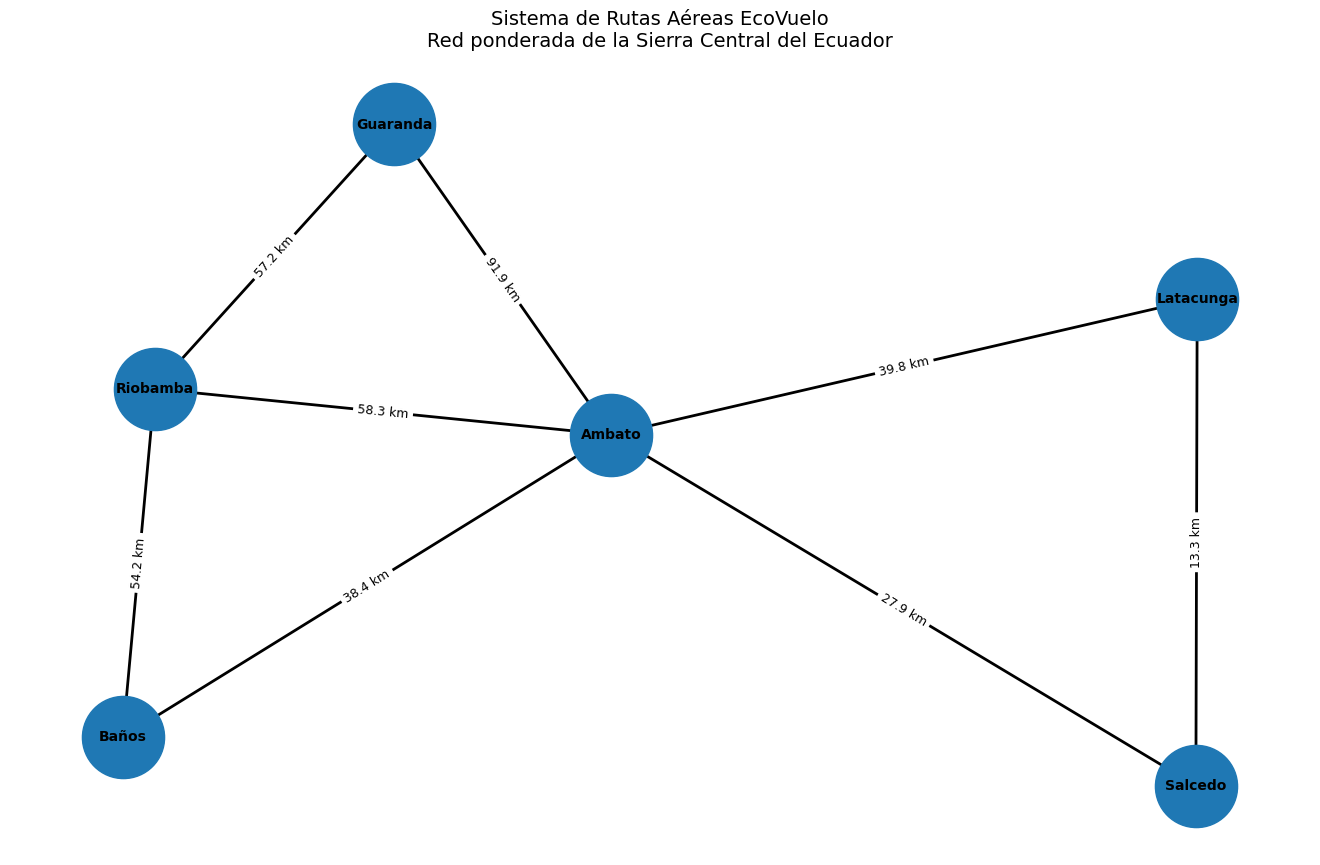

In [ ]:
# Crear el espacio de la figura

plt.figure(figsize=(13, 8))

# Calcular una posición estable para cada ciudad

posiciones = nx.spring_layout(
    grafo,
    seed=42,
    k=1.3
)

# Dibujar las ciudades y las rutas

nx.draw(
    grafo,
    posiciones,
    with_labels=True,
    node_size=3500,
    font_size=10,
    font_weight="bold",
    width=2
)

# Obtener las distancias almacenadas en las rutas

distancias = nx.get_edge_attributes(grafo, "weight")

# Crear las etiquetas con un decimal y la unidad km

etiquetas_distancias = {
    ruta: f"{distancia:.1f} km"
    for ruta, distancia in distancias.items()
}

# Mostrar las distancias sobre cada ruta

nx.draw_networkx_edge_labels(
    grafo,
    posiciones,
    edge_labels=etiquetas_distancias,
    font_size=9
)

# Agregar el título de la visualización

plt.title(
    "Sistema de Rutas Aéreas EcoVuelo\n"
    "Red ponderada de la Sierra Central del Ecuador",
    fontsize=14
)

# Ocultar los ejes del gráfico

plt.axis("off")

# Mostrar la visualización

plt.show()

## Explicación general de la segunda etapa

En la segunda etapa del proyecto se construyó la red inicial del Sistema de Rutas Aéreas EcoVuelo mediante la conexión de las seis ciudades previamente registradas.

Para representar las rutas directas se utilizaron aristas ponderadas. Cada arista conecta dos ciudades y almacena como peso la distancia establecida en kilómetros. Debido a que el grafo es no dirigido, cada ruta puede recorrerse en ambos sentidos sin necesidad de registrar dos conexiones diferentes.

Las rutas se almacenaron en una lista de tuplas. Cada tupla contiene tres elementos: la primera ciudad, la segunda ciudad y la distancia que existe entre ellas. Posteriormente, la función `add_weighted_edges_from()` agregó todas las conexiones y guardó cada distancia en el atributo denominado `weight`.

Después de registrar las rutas, el programa recorrió las aristas para mostrar las ciudades conectadas y sus respectivas distancias. También comprobó que la red estuviera formada por un total de seis ciudades y ocho rutas.

Finalmente, se generó una representación visual de la red utilizando NetworkX y Matplotlib. En el gráfico, los nodos representan las ciudades, las líneas representan las rutas directas y las etiquetas sobre cada conexión muestran las distancias en kilómetros.

La segunda etapa permitió convertir el conjunto inicial de ciudades en una red conectada y ponderada. Esta estructura servirá como base para desarrollar las operaciones de gestión, consulta y recorrido solicitadas en la actividad.

## Tercera etapa: desarrollo de las operaciones del sistema

En esta etapa se programarán las funciones que permitirán al usuario administrar y consultar la red de rutas aéreas EcoVuelo.

Las operaciones actuarán directamente sobre el grafo creado en las etapas anteriores. El usuario podrá agregar y eliminar ciudades, registrar y cancelar rutas, buscar elementos, consultar distancias, conocer los destinos directos y calcular la conectividad de cada ciudad.

Cada función incluirá validaciones para impedir que una entrada incorrecta altere la estructura del grafo o provoque la interrupción del programa.

La primera operación que se desarrollará será añadir una ciudad. Esta función permitirá registrar un nuevo nodo en la red, siempre que el nombre ingresado sea válido y que la ciudad no se encuentre registrada anteriormente.

In [ ]:
# Función auxiliar para localizar una ciudad sin diferenciar
# entre letras mayúsculas y minúsculas

def encontrar_ciudad(grafo, nombre_ciudad):
    """
    Busca una ciudad dentro del grafo.

    Retorna el nombre almacenado en el grafo cuando la ciudad existe.
    Retorna None cuando no se encuentra registrada.
    """

    # Verificar que el dato ingresado sea texto
    if not isinstance(nombre_ciudad, str):
        return None

    # Eliminar espacios innecesarios al inicio y al final
    nombre_buscado = nombre_ciudad.strip()

    # Comparar el nombre ingresado con todos los nodos existentes
    for ciudad in grafo.nodes:
        if ciudad.casefold() == nombre_buscado.casefold():
            return ciudad

    return None


def agregar_ciudad(grafo, nombre_ciudad):
    """
    Agrega una nueva ciudad al grafo EcoVuelo.
    """

    # Validar que el nombre sea un texto
    if not isinstance(nombre_ciudad, str):
        return "Error: el nombre de la ciudad debe ser un texto."

    # Eliminar espacios innecesarios
    nombre_limpio = nombre_ciudad.strip()

    # Validar que el nombre no esté vacío
    if nombre_limpio == "":
        return "Error: debe ingresar el nombre de una ciudad."

    # Comprobar si la ciudad ya existe
    ciudad_existente = encontrar_ciudad(grafo, nombre_limpio)

    if ciudad_existente is not None:
        return f"Error: la ciudad {ciudad_existente} ya está registrada."

    # Dar un formato uniforme al nombre
    nombre_formateado = nombre_limpio.title()

    # Agregar la ciudad como un nuevo nodo
    grafo.add_node(nombre_formateado)

    return (
        f"Ciudad {nombre_formateado} agregada correctamente. "
        f"Total de ciudades: {grafo.number_of_nodes()}."
    )

In [ ]:
# Primera prueba: agregar una ciudad nueva

resultado = agregar_ciudad(grafo, "Pujilí")

print(resultado)

Ciudad Pujilí agregada correctamente. Total de ciudades: 7.


In [ ]:
# Segunda prueba: intentar registrar nuevamente la misma ciudad

resultado = agregar_ciudad(grafo, "Pujilí")

print(resultado)

Error: la ciudad Pujilí ya está registrada.


In [ ]:
# Tercera prueba: ingresar la ciudad con una escritura diferente

resultado = agregar_ciudad(grafo, "PUJILÍ")

print(resultado)

Error: la ciudad Pujilí ya está registrada.


In [ ]:
# Cuarta prueba: intentar agregar un nombre vacío

resultado = agregar_ciudad(grafo, "   ")

print(resultado)

Error: debe ingresar el nombre de una ciudad.


In [ ]:
# Mostrar todas las ciudades después de realizar las pruebas

print("Ciudades actualmente registradas en EcoVuelo:\n")

for numero, ciudad in enumerate(grafo.nodes, start=1):
    print(f"{numero}. {ciudad}")

print("\nTotal de ciudades:", grafo.number_of_nodes())

Ciudades actualmente registradas en EcoVuelo:

1. Latacunga
2. Salcedo
3. Ambato
4. Baños
5. Riobamba
6. Guaranda
7. Pujilí

Total de ciudades: 7


### Explicación general de la operación Añadir Ciudad

La primera operación desarrollada permite agregar una nueva ciudad como nodo del Sistema EcoVuelo.

Para realizar esta operación se creó inicialmente una función auxiliar denominada `encontrar_ciudad()`. Su finalidad es comprobar si un nombre ya está registrado, sin diferenciar entre letras mayúsculas y minúsculas.

Posteriormente, se creó la función `agregar_ciudad()`, que recibe el grafo y el nombre de la ciudad. Antes de insertar el nuevo nodo, la función valida que el dato sea un texto, elimina los espacios innecesarios, impide el ingreso de nombres vacíos y verifica que la ciudad no exista previamente.

Para comprobar el funcionamiento se agregó la ciudad de Pujilí. El sistema confirmó que el nuevo nodo fue registrado y que la red pasó de seis a siete ciudades.

También se realizaron pruebas con un nombre repetido, una escritura en mayúsculas y una entrada vacía. En todos estos casos, el sistema mostró mensajes de error y evitó modificar incorrectamente la estructura del grafo.

Estas validaciones permiten que la operación sea segura y que la red no contenga ciudades duplicadas o nombres inválidos.

## Cuarta etapa: operación Buscar Ciudad

En esta etapa se desarrollará la operación Buscar Ciudad, cuya finalidad es comprobar si una ciudad se encuentra registrada como nodo dentro del Sistema de Rutas Aéreas EcoVuelo.

La operación recibirá el nombre ingresado por el usuario y buscará una coincidencia entre los nodos existentes del grafo. La búsqueda no diferenciará entre letras mayúsculas y minúsculas. Por esta razón, nombres como `Ambato`, `ambato` y `AMBATO` serán reconocidos como la misma ciudad.

Antes de realizar la búsqueda, el programa verificará que el dato ingresado sea un texto y que no se encuentre vacío. Si la ciudad existe, el sistema mostrará un mensaje de confirmación. Si no está registrada, informará que no fue encontrada sin interrumpir la ejecución del programa.

Esta operación será únicamente de consulta. Por lo tanto, no agregará, eliminará ni modificará ninguna ciudad o ruta almacenada en el grafo.

In [ ]:
# Operación 2: Buscar Ciudad o Verificar Vértice

def buscar_ciudad(grafo, nombre_ciudad):
    """
    Comprueba si una ciudad se encuentra registrada en el grafo.

    Parámetros:
    grafo: estructura que contiene la red EcoVuelo.
    nombre_ciudad: nombre que se desea buscar.

    Retorna:
    Un mensaje indicando si la ciudad existe o no.
    """

    # Validar que el dato ingresado sea texto
    if not isinstance(nombre_ciudad, str):
        return "Error: el nombre de la ciudad debe ser un texto."

    # Eliminar espacios innecesarios al inicio y al final
    nombre_limpio = nombre_ciudad.strip()

    # Validar que el nombre no esté vacío
    if nombre_limpio == "":
        return "Error: debe ingresar el nombre de una ciudad."

    # Utilizar la función auxiliar creada anteriormente
    ciudad_encontrada = encontrar_ciudad(grafo, nombre_limpio)

    # Comprobar el resultado de la búsqueda
    if ciudad_encontrada is not None:
        return f"La ciudad {ciudad_encontrada} sí está registrada en EcoVuelo."

    # Formatear el nombre solamente para mostrarlo en el mensaje
    nombre_formateado = nombre_limpio.title()

    return f"La ciudad {nombre_formateado} no está registrada en EcoVuelo."

In [ ]:
# Primera prueba: buscar una ciudad registrada

resultado = buscar_ciudad(grafo, "Ambato")

print(resultado)

La ciudad Ambato sí está registrada en EcoVuelo.


In [ ]:
# Segunda prueba: buscar una ciudad utilizando minúsculas

resultado = buscar_ciudad(grafo, "ambato")

print(resultado)

La ciudad Ambato sí está registrada en EcoVuelo.


In [ ]:
# Tercera prueba: buscar la ciudad agregada en la operación anterior

resultado = buscar_ciudad(grafo, "Pujilí")

print(resultado)

La ciudad Pujilí sí está registrada en EcoVuelo.


In [ ]:
# Cuarta prueba: buscar una ciudad no registrada

resultado = buscar_ciudad(grafo, "Quito")

print(resultado)

La ciudad Quito no está registrada en EcoVuelo.


In [ ]:
# Quinta prueba: intentar buscar una ciudad sin ingresar un nombre

resultado = buscar_ciudad(grafo, "   ")

print(resultado)

Error: debe ingresar el nombre de una ciudad.


In [ ]:
# Sexta prueba: ingresar un número en lugar de un nombre

resultado = buscar_ciudad(grafo, 123)

print(resultado)

Error: el nombre de la ciudad debe ser un texto.


In [ ]:
# Pruebas generales de la operación Buscar Ciudad

total_antes = grafo.number_of_nodes()

pruebas_busqueda = [
    "Ambato",
    "ambato",
    "Pujilí",
    "Quito",
    "   ",
    123
]

print("PRUEBAS DE LA OPERACIÓN BUSCAR CIUDAD\n")

for entrada in pruebas_busqueda:
    print(f"Entrada utilizada: {repr(entrada)}")
    print(buscar_ciudad(grafo, entrada))
    print("-" * 55)

total_despues = grafo.number_of_nodes()

print("\nTotal de ciudades antes de las búsquedas:", total_antes)
print("Total de ciudades después de las búsquedas:", total_despues)

if total_antes == total_despues:
    print("Comprobación correcta: las búsquedas no modificaron el grafo.")
else:
    print("Advertencia: la cantidad de ciudades cambió.")

PRUEBAS DE LA OPERACIÓN BUSCAR CIUDAD

Entrada utilizada: 'Ambato'
La ciudad Ambato sí está registrada en EcoVuelo.
-------------------------------------------------------
Entrada utilizada: 'ambato'
La ciudad Ambato sí está registrada en EcoVuelo.
-------------------------------------------------------
Entrada utilizada: 'Pujilí'
La ciudad Pujilí sí está registrada en EcoVuelo.
-------------------------------------------------------
Entrada utilizada: 'Quito'
La ciudad Quito no está registrada en EcoVuelo.
-------------------------------------------------------
Entrada utilizada: '   '
Error: debe ingresar el nombre de una ciudad.
-------------------------------------------------------
Entrada utilizada: 123
Error: el nombre de la ciudad debe ser un texto.
-------------------------------------------------------

Total de ciudades antes de las búsquedas: 7
Total de ciudades después de las búsquedas: 7
Comprobación correcta: las búsquedas no modificaron el grafo.


In [ ]:
# Búsqueda interactiva de una ciudad

nombre_consultado = input(
    "Ingrese el nombre de la ciudad que desea buscar: "
)

resultado = buscar_ciudad(grafo, nombre_consultado)

print("\nResultado de la búsqueda:")
print(resultado)

Ingrese el nombre de la ciudad que desea buscar: riobamba

Resultado de la búsqueda:
La ciudad Riobamba sí está registrada en EcoVuelo.


## Explicación general de la cuarta etapa

En la cuarta etapa se desarrolló la operación Buscar Ciudad, encargada de verificar si un determinado nombre se encuentra registrado como nodo dentro del Sistema de Rutas Aéreas EcoVuelo.

Para implementar esta operación se creó la función `buscar_ciudad()`. La función recibe el grafo y el nombre que se desea consultar. Antes de realizar la búsqueda, comprueba que el dato sea un texto, elimina los espacios innecesarios y evita que se procesen nombres vacíos.

La búsqueda utiliza la función auxiliar `encontrar_ciudad()`, desarrollada anteriormente. Esta función permite comparar el nombre ingresado con los nodos existentes sin diferenciar entre letras mayúsculas y minúsculas.

Para comprobar su funcionamiento se realizaron búsquedas de ciudades registradas, como Ambato y Pujilí, y de una ciudad no registrada, como Quito. También se probaron entradas incorrectas, incluyendo un nombre vacío y un valor numérico.

En todos los casos, el programa mostró un mensaje claro y continuó funcionando normalmente. Además, se comprobó que la cantidad de ciudades antes y después de las consultas permaneciera igual, demostrando que esta operación únicamente consulta la información y no modifica la estructura del grafo.

Con esta etapa queda completada la operación Buscar Ciudad o Verificar Vértice.

## Quinta etapa: operación Eliminar Ciudad

En esta etapa se desarrollará la operación Eliminar Ciudad, cuya finalidad es retirar un nodo del Sistema de Rutas Aéreas EcoVuelo.

Antes de realizar la eliminación, el programa comprobará que el nombre ingresado sea válido y que la ciudad se encuentre registrada dentro del grafo. Si la ciudad no existe, el sistema mostrará un mensaje informativo y conservará la red sin modificaciones.

Cuando una ciudad sea eliminada, también deberán desaparecer automáticamente todas las rutas conectadas con ella. Esta validación es necesaria para evitar conexiones huérfanas, es decir, rutas asociadas con un nodo que ya no forma parte del sistema.

La operación informará el nombre de la ciudad eliminada, la cantidad de rutas retiradas y el número total de ciudades y conexiones que permanecen en la red.

Para comprobar el funcionamiento sin alterar inicialmente el grafo principal, se creará una copia temporal de la red. Sobre esa copia se eliminará una ciudad con varias conexiones y se verificará que todas sus rutas también hayan sido retiradas.

In [ ]:
# Operación 3: Eliminar Ciudad o Eliminar Vértice

def eliminar_ciudad(grafo, nombre_ciudad):
    """
    Elimina una ciudad del grafo y todas las rutas conectadas con ella.

    Parámetros:
    grafo: estructura que contiene la red EcoVuelo.
    nombre_ciudad: nombre de la ciudad que se desea eliminar.

    Retorna:
    Un mensaje con el resultado de la operación.
    """

    # Validar que el dato ingresado sea texto
    if not isinstance(nombre_ciudad, str):
        return "Error: el nombre de la ciudad debe ser un texto."

    # Eliminar espacios innecesarios
    nombre_limpio = nombre_ciudad.strip()

    # Validar que el nombre no esté vacío
    if nombre_limpio == "":
        return "Error: debe ingresar el nombre de una ciudad."

    # Buscar la ciudad sin diferenciar mayúsculas y minúsculas
    ciudad_encontrada = encontrar_ciudad(grafo, nombre_limpio)

    # Comprobar si la ciudad existe
    if ciudad_encontrada is None:
        nombre_formateado = nombre_limpio.title()

        return (
            f"Error: la ciudad {nombre_formateado} "
            "no está registrada en EcoVuelo."
        )

    # Contar las rutas conectadas antes de eliminar la ciudad
    rutas_conectadas = list(
        grafo.edges(ciudad_encontrada, data=True)
    )

    cantidad_rutas = len(rutas_conectadas)

    # Eliminar la ciudad
    # NetworkX también elimina automáticamente sus rutas
    grafo.remove_node(ciudad_encontrada)

    return (
        f"Ciudad {ciudad_encontrada} eliminada correctamente. "
        f"Rutas eliminadas: {cantidad_rutas}. "
        f"Ciudades restantes: {grafo.number_of_nodes()}. "
        f"Rutas restantes: {grafo.number_of_edges()}."
    )

In [ ]:
# Primera prueba: eliminar una ciudad no registrada

resultado = eliminar_ciudad(grafo, "Quito")

print(resultado)

Error: la ciudad Quito no está registrada en EcoVuelo.


In [ ]:
# Segunda prueba: intentar eliminar una ciudad sin escribir un nombre

resultado = eliminar_ciudad(grafo, "   ")

print(resultado)

Error: debe ingresar el nombre de una ciudad.


In [ ]:
# Tercera prueba: ingresar un número en lugar de un nombre

resultado = eliminar_ciudad(grafo, 123)

print(resultado)

Error: el nombre de la ciudad debe ser un texto.


In [ ]:
# Crear una copia del grafo para realizar una prueba segura

grafo_prueba = grafo.copy()

print("PRUEBA DE ELIMINACIÓN DE AMBATO\n")

print(
    "Ciudades antes de la eliminación:",
    grafo_prueba.number_of_nodes()
)

print(
    "Rutas antes de la eliminación:",
    grafo_prueba.number_of_edges()
)

# Mostrar las rutas conectadas con Ambato

print("\nRutas conectadas con Ambato:")

for origen, destino, datos in grafo_prueba.edges(
    "Ambato",
    data=True
):
    distancia = datos["weight"]

    print(
        f"- {origen} ↔ {destino}: "
        f"{distancia:.1f} km"
    )

PRUEBA DE ELIMINACIÓN DE AMBATO

Ciudades antes de la eliminación: 7
Rutas antes de la eliminación: 8

Rutas conectadas con Ambato:
- Ambato ↔ Latacunga: 39.8 km
- Ambato ↔ Salcedo: 27.9 km
- Ambato ↔ Baños: 38.4 km
- Ambato ↔ Riobamba: 58.3 km
- Ambato ↔ Guaranda: 91.9 km


In [ ]:
# Eliminar Ambato únicamente de la copia del grafo

resultado = eliminar_ciudad(
    grafo_prueba,
    "ambato"
)

print(resultado)

Ciudad Ambato eliminada correctamente. Rutas eliminadas: 5. Ciudades restantes: 6. Rutas restantes: 3.


In [ ]:
# Comprobar el resultado después de eliminar Ambato

print("COMPROBACIÓN DESPUÉS DE LA ELIMINACIÓN\n")

print(
    "¿Ambato continúa registrado?",
    grafo_prueba.has_node("Ambato")
)

print(
    "Ciudades restantes:",
    grafo_prueba.number_of_nodes()
)

print(
    "Rutas restantes:",
    grafo_prueba.number_of_edges()
)

print("\nRutas que permanecen en la copia:")

for origen, destino, datos in grafo_prueba.edges(data=True):
    distancia = datos["weight"]

    print(
        f"- {origen} ↔ {destino}: "
        f"{distancia:.1f} km"
    )

COMPROBACIÓN DESPUÉS DE LA ELIMINACIÓN

¿Ambato continúa registrado? False
Ciudades restantes: 6
Rutas restantes: 3

Rutas que permanecen en la copia:
- Latacunga ↔ Salcedo: 13.3 km
- Baños ↔ Riobamba: 54.2 km
- Riobamba ↔ Guaranda: 57.2 km


In [ ]:
# Verificar automáticamente que no existan rutas huérfanas

rutas_huerfanas = []

for origen, destino in grafo_prueba.edges():
    if (
        origen not in grafo_prueba.nodes
        or destino not in grafo_prueba.nodes
    ):
        rutas_huerfanas.append(
            (origen, destino)
        )

if len(rutas_huerfanas) == 0:
    print(
        "Comprobación correcta: "
        "no existen rutas huérfanas."
    )
else:
    print(
        "Advertencia: se encontraron rutas huérfanas:",
        rutas_huerfanas
    )

Comprobación correcta: no existen rutas huérfanas.


In [ ]:
# Comprobar que la red original no fue modificada

print("ESTADO DEL GRAFO ORIGINAL\n")

print(
    "¿Ambato está registrado?",
    grafo.has_node("Ambato")
)

print(
    "Total de ciudades:",
    grafo.number_of_nodes()
)

print(
    "Total de rutas:",
    grafo.number_of_edges()
)

ESTADO DEL GRAFO ORIGINAL

¿Ambato está registrado? True
Total de ciudades: 7
Total de rutas: 8


In [ ]:
# Eliminar del grafo original la ciudad agregada como prueba

resultado = eliminar_ciudad(
    grafo,
    "Pujilí"
)

print(resultado)

Ciudad Pujilí eliminada correctamente. Rutas eliminadas: 0. Ciudades restantes: 6. Rutas restantes: 8.


In [ ]:
# Mostrar las ciudades y rutas del grafo principal

print("ESTADO FINAL DEL SISTEMA ECOVUELO\n")

print("Ciudades registradas:")

for numero, ciudad in enumerate(
    grafo.nodes,
    start=1
):
    print(f"{numero}. {ciudad}")

print(
    "\nTotal de ciudades:",
    grafo.number_of_nodes()
)

print(
    "Total de rutas:",
    grafo.number_of_edges()
)

ESTADO FINAL DEL SISTEMA ECOVUELO

Ciudades registradas:
1. Latacunga
2. Salcedo
3. Ambato
4. Baños
5. Riobamba
6. Guaranda

Total de ciudades: 6
Total de rutas: 8


In [ ]:
# Eliminación interactiva de una ciudad

nombre_eliminar = input(
    "Ingrese el nombre de la ciudad que desea eliminar: "
)

confirmacion = input(
    f"¿Confirma la eliminación de {nombre_eliminar}? "
    "Escriba SI para continuar: "
)

if confirmacion.strip().casefold() == "si":
    resultado = eliminar_ciudad(
        grafo,
        nombre_eliminar
    )

    print("\nResultado:")
    print(resultado)

else:
    print(
        "\nOperación cancelada. "
        "El grafo no fue modificado."
    )

¿Confirma la eliminación de jajja? Escriba SI para continuar: si

Resultado:
Error: la ciudad Jajja no está registrada en EcoVuelo.


## Explicación general de la quinta etapa

En la quinta etapa se desarrolló la operación Eliminar Ciudad, correspondiente a la eliminación de un vértice dentro del Sistema de Rutas Aéreas EcoVuelo.

La función `eliminar_ciudad()` recibe el grafo y el nombre de la ciudad que se desea retirar. Antes de modificar la red, comprueba que el dato ingresado sea un texto, elimina los espacios innecesarios y evita que se procesen nombres vacíos.

Posteriormente, utiliza la función auxiliar `encontrar_ciudad()` para verificar si el nodo está registrado, sin diferenciar entre letras mayúsculas y minúsculas. Si la ciudad no existe, el sistema muestra un mensaje de error y conserva el grafo sin modificaciones.

Cuando la ciudad existe, la función obtiene y cuenta todas las rutas conectadas con ella. Después utiliza `remove_node()` para eliminar el nodo. NetworkX elimina automáticamente las aristas relacionadas, evitando que permanezcan rutas huérfanas dentro de la red.

Para comprobar esta operación se creó una copia temporal del grafo y se eliminó la ciudad de Ambato. Antes de la eliminación, Ambato mantenía cinco conexiones directas. Después de ejecutar la función, el nodo desapareció junto con sus cinco rutas y la copia quedó con solamente tres conexiones.

También se realizó una comprobación automática para verificar que todas las rutas restantes estuvieran asociadas con ciudades existentes. El resultado confirmó que no quedaron conexiones huérfanas.

Finalmente, se comprobó que el grafo original permaneciera intacto, porque la eliminación de Ambato se realizó únicamente sobre una copia de prueba. La ciudad de Pujilí, agregada anteriormente para probar la primera operación, fue eliminada del grafo principal para recuperar la configuración inicial de seis ciudades y ocho rutas.

Con esta etapa queda completada la operación Eliminar Ciudad o Eliminar Vértice.

## Sexta etapa: operación Añadir Ruta Ponderada

En esta etapa se desarrollará la operación Añadir Ruta Ponderada, cuya finalidad es crear una conexión directa entre dos ciudades que ya se encuentren registradas en el Sistema de Rutas Aéreas EcoVuelo.

La función recibirá tres datos: la ciudad de origen, la ciudad de destino y la distancia en kilómetros. Antes de agregar la ruta, el programa verificará que los nombres ingresados sean válidos, que ambas ciudades existan, que no se intente conectar una ciudad consigo misma y que la distancia sea un valor numérico mayor que cero.

También se comprobará que la ruta no esté registrada anteriormente. Esta validación evitará que una conexión existente sea reemplazada o duplicada accidentalmente.

Cuando todos los datos sean correctos, el sistema agregará una nueva arista entre las dos ciudades y almacenará la distancia en el atributo `weight`.

Para comprobar la función sin alterar la red principal de EcoVuelo, se utilizará una copia temporal del grafo. En esa copia se retirará una ruta conocida y posteriormente se volverá a registrar utilizando la nueva función.

In [ ]:
# Importar math para validar que la distancia sea un número finito

import math


# Operación 4: Añadir Ruta o Agregar Arista Ponderada

def agregar_ruta(grafo, ciudad_origen, ciudad_destino, distancia):
    """
    Agrega una ruta ponderada entre dos ciudades existentes.

    Parámetros:
    grafo: red de ciudades y rutas de EcoVuelo.
    ciudad_origen: primera ciudad de la conexión.
    ciudad_destino: segunda ciudad de la conexión.
    distancia: peso de la ruta expresado en kilómetros.

    Retorna:
    Un mensaje indicando el resultado de la operación.
    """

    # Validar que el nombre de origen sea texto
    if not isinstance(ciudad_origen, str):
        return "Error: la ciudad de origen debe ingresarse como texto."

    # Validar que el nombre de destino sea texto
    if not isinstance(ciudad_destino, str):
        return "Error: la ciudad de destino debe ingresarse como texto."

    # Eliminar espacios innecesarios
    origen_limpio = ciudad_origen.strip()
    destino_limpio = ciudad_destino.strip()

    # Validar que el nombre de origen no esté vacío
    if origen_limpio == "":
        return "Error: debe ingresar la ciudad de origen."

    # Validar que el nombre de destino no esté vacío
    if destino_limpio == "":
        return "Error: debe ingresar la ciudad de destino."

    # Buscar los nombres reales almacenados en el grafo
    origen_encontrado = encontrar_ciudad(
        grafo,
        origen_limpio
    )

    destino_encontrado = encontrar_ciudad(
        grafo,
        destino_limpio
    )

    # Verificar que la ciudad de origen exista
    if origen_encontrado is None:
        return (
            f"Error: la ciudad {origen_limpio.title()} "
            "no está registrada en EcoVuelo."
        )

    # Verificar que la ciudad de destino exista
    if destino_encontrado is None:
        return (
            f"Error: la ciudad {destino_limpio.title()} "
            "no está registrada en EcoVuelo."
        )

    # Evitar que una ciudad se conecte consigo misma
    if origen_encontrado == destino_encontrado:
        return (
            "Error: no se puede crear una ruta desde una ciudad "
            "hacia la misma ciudad."
        )

    # Validar que la distancia sea un número
    if (
        not isinstance(distancia, (int, float))
        or isinstance(distancia, bool)
    ):
        return "Error: la distancia debe ser un valor numérico."

    # Validar que la distancia no sea infinita ni indefinida
    if not math.isfinite(distancia):
        return "Error: la distancia ingresada no es válida."

    # Validar que la distancia sea mayor que cero
    if distancia <= 0:
        return "Error: la distancia debe ser mayor que cero kilómetros."

    # Comprobar si la ruta ya existe
    if grafo.has_edge(origen_encontrado, destino_encontrado):
        distancia_actual = grafo[
            origen_encontrado
        ][destino_encontrado]["weight"]

        return (
            f"Error: la ruta entre {origen_encontrado} y "
            f"{destino_encontrado} ya está registrada con una "
            f"distancia de {distancia_actual:.1f} km."
        )

    # Agregar la nueva ruta y almacenar su distancia
    grafo.add_edge(
        origen_encontrado,
        destino_encontrado,
        weight=float(distancia)
    )

    return (
        f"Ruta {origen_encontrado} ↔ {destino_encontrado} "
        f"agregada correctamente con una distancia de "
        f"{distancia:.1f} km. "
        f"Total de rutas: {grafo.number_of_edges()}."
    )

In [ ]:
# Primera prueba: ciudad de origen no registrada

resultado = agregar_ruta(
    grafo,
    "Quito",
    "Ambato",
    120.0
)

print(resultado)

Error: la ciudad Quito no está registrada en EcoVuelo.


In [ ]:
# Segunda prueba: ciudad de destino no registrada

resultado = agregar_ruta(
    grafo,
    "Ambato",
    "Cuenca",
    190.0
)

print(resultado)

Error: la ciudad Cuenca no está registrada en EcoVuelo.


In [ ]:
# Tercera prueba: origen y destino iguales

resultado = agregar_ruta(
    grafo,
    "Ambato",
    "ambato",
    10.0
)

print(resultado)

Error: no se puede crear una ruta desde una ciudad hacia la misma ciudad.


In [ ]:
# Cuarta prueba: distancia ingresada como texto

resultado = agregar_ruta(
    grafo,
    "Latacunga",
    "Baños",
    "75.0"
)

print(resultado)

Error: la ciudad Baños no está registrada en EcoVuelo.


In [ ]:
# Quinta prueba: distancia negativa

resultado = agregar_ruta(
    grafo,
    "Latacunga",
    "Baños",
    -75.0
)

print(resultado)

Error: la ciudad Baños no está registrada en EcoVuelo.


In [ ]:
# Sexta prueba: distancia igual a cero

resultado = agregar_ruta(
    grafo,
    "Latacunga",
    "Baños",
    0
)

print(resultado)

Error: la ciudad Baños no está registrada en EcoVuelo.


In [ ]:
# Séptima prueba: intentar agregar una ruta repetida

resultado = agregar_ruta(
    grafo,
    "salcedo",
    "LATACUNGA",
    13.3
)

print(resultado)

Error: la ruta entre Salcedo y Latacunga ya está registrada con una distancia de 13.3 km.


In [ ]:
# Crear una copia del grafo para probar la nueva operación

grafo_prueba_ruta = grafo.copy()

# Eliminar temporalmente una ruta conocida de la copia

grafo_prueba_ruta.remove_edge(
    "Latacunga",
    "Salcedo"
)

print("ESTADO DE LA COPIA ANTES DE AGREGAR LA RUTA\n")

print(
    "Total de ciudades:",
    grafo_prueba_ruta.number_of_nodes()
)

print(
    "Total de rutas:",
    grafo_prueba_ruta.number_of_edges()
)

print(
    "¿Existe la ruta Latacunga - Salcedo?",
    grafo_prueba_ruta.has_edge(
        "Latacunga",
        "Salcedo"
    )
)

ESTADO DE LA COPIA ANTES DE AGREGAR LA RUTA

Total de ciudades: 5
Total de rutas: 5
¿Existe la ruta Latacunga - Salcedo? False


In [ ]:
# Agregar la ruta mediante la función desarrollada

resultado = agregar_ruta(
    grafo_prueba_ruta,
    "latacunga",
    "SALCEDO",
    13.3
)

print(resultado)

Ruta Latacunga ↔ Salcedo agregada correctamente con una distancia de 13.3 km. Total de rutas: 6.


In [ ]:
# Comprobar que la ruta fue almacenada correctamente

existe_ruta = grafo_prueba_ruta.has_edge(
    "Latacunga",
    "Salcedo"
)

distancia_guardada = grafo_prueba_ruta[
    "Latacunga"
]["Salcedo"]["weight"]

print("COMPROBACIÓN DE LA RUTA AGREGADA\n")

print(
    "¿Existe la ruta Latacunga - Salcedo?",
    existe_ruta
)

print(
    f"Distancia almacenada: "
    f"{distancia_guardada:.1f} km"
)

print(
    "Total de rutas:",
    grafo_prueba_ruta.number_of_edges()
)

COMPROBACIÓN DE LA RUTA AGREGADA

¿Existe la ruta Latacunga - Salcedo? True
Distancia almacenada: 13.3 km
Total de rutas: 6


In [ ]:
# Verificar que la red principal permanezca intacta

print("ESTADO DEL GRAFO PRINCIPAL\n")

print(
    "Total de ciudades:",
    grafo.number_of_nodes()
)

print(
    "Total de rutas:",
    grafo.number_of_edges()
)

print(
    "¿La ruta Latacunga - Salcedo continúa registrada?",
    grafo.has_edge(
        "Latacunga",
        "Salcedo"
    )
)

print(
    "Distancia original:",
    f"{grafo['Latacunga']['Salcedo']['weight']:.1f} km"
)

In [ ]:
# Prueba interactiva segura de la operación Añadir Ruta

grafo_interactivo = grafo.copy()

origen_usuario = input(
    "Ingrese la ciudad de origen: "
)

destino_usuario = input(
    "Ingrese la ciudad de destino: "
)

distancia_usuario = input(
    "Ingrese la distancia en kilómetros: "
)

try:
    distancia_convertida = float(
        distancia_usuario
    )

    resultado = agregar_ruta(
        grafo_interactivo,
        origen_usuario,
        destino_usuario,
        distancia_convertida
    )

except ValueError:
    resultado = (
        "Error: la distancia debe escribirse "
        "utilizando solamente números."
    )

print("\nResultado:")
print(resultado)

Ingrese la ciudad de origen: ambato
Ingrese la ciudad de destino: baños
Ingrese la distancia en kilómetros: 4949

Resultado:
Error: la ruta entre Ambato y Baños ya está registrada con una distancia de 38.4 km.


In [ ]:
# Restauración completa de Baños y sus rutas originales

print("RESTAURACIÓN DE BAÑOS\n")

# 1. Restaurar la ciudad si no existe

if encontrar_ciudad(grafo, "Baños") is None:
    print(agregar_ciudad(grafo, "Baños"))
else:
    print("La ciudad Baños ya está registrada.")

# 2. Restaurar la ruta Ambato - Baños si no existe

if not grafo.has_edge("Ambato", "Baños"):
    print(
        agregar_ruta(
            grafo,
            "Ambato",
            "Baños",
            38.4
        )
    )
else:
    print("La ruta Ambato ↔ Baños ya está registrada.")

# 3. Restaurar la ruta Baños - Riobamba si no existe

if not grafo.has_edge("Baños", "Riobamba"):
    print(
        agregar_ruta(
            grafo,
            "Baños",
            "Riobamba",
            54.2
        )
    )
else:
    print("La ruta Baños ↔ Riobamba ya está registrada.")

RESTAURACIÓN DE BAÑOS

Ciudad Baños agregada correctamente. Total de ciudades: 6.
Ruta Ambato ↔ Baños agregada correctamente con una distancia de 38.4 km. Total de rutas: 7.
Ruta Baños ↔ Riobamba agregada correctamente con una distancia de 54.2 km. Total de rutas: 8.


In [ ]:
# Verificación del estado de Baños

print("\nCOMPROBACIÓN FINAL\n")

print(
    "Baños registrado:",
    encontrar_ciudad(grafo, "Baños") is not None
)

print(
    "Ruta Ambato - Baños:",
    grafo.has_edge("Ambato", "Baños")
)

print(
    "Ruta Baños - Riobamba:",
    grafo.has_edge("Baños", "Riobamba")
)

print(
    "Total de ciudades:",
    grafo.number_of_nodes()
)

print(
    "Total de rutas:",
    grafo.number_of_edges()
)


COMPROBACIÓN FINAL

Baños registrado: True
Ruta Ambato - Baños: True
Ruta Baños - Riobamba: True
Total de ciudades: 6
Total de rutas: 8


## Explicación general de la sexta etapa

En la sexta etapa se desarrolló la operación Añadir Ruta Ponderada, encargada de crear una conexión directa entre dos ciudades existentes del Sistema de Rutas Aéreas EcoVuelo.

Para realizar esta operación se creó la función `agregar_ruta()`, que recibe el grafo, la ciudad de origen, la ciudad de destino y la distancia en kilómetros.

Antes de modificar la red, la función verifica que los nombres ingresados sean textos válidos y elimina los espacios innecesarios. Posteriormente, utiliza la función auxiliar `encontrar_ciudad()` para localizar los nombres almacenados en el grafo sin diferenciar entre letras mayúsculas y minúsculas.

La función también comprueba que ambas ciudades se encuentren registradas, evita que una ciudad se conecte consigo misma y valida que la distancia sea un número finito mayor que cero.

Antes de agregar la conexión se utiliza `has_edge()` para comprobar que la ruta no exista previamente. Esta validación evita que una ruta registrada sea duplicada o que su distancia sea reemplazada accidentalmente.

Cuando todos los datos son correctos, la función utiliza `add_edge()` para crear la conexión y almacena la distancia en el atributo `weight`.

Para comprobar el funcionamiento se realizaron pruebas con ciudades inexistentes, nombres vacíos, una conexión hacia la misma ciudad, una distancia ingresada como texto, valores negativos, cero kilómetros y una ruta repetida. En todos estos casos, el programa mostró mensajes de error y conservó la estructura del grafo sin modificaciones.

La prueba correcta se realizó sobre una copia temporal de la red. Primero se eliminó la ruta entre Latacunga y Salcedo y posteriormente se volvió a registrar con una distancia de 13,3 kilómetros. El sistema confirmó que la conexión fue añadida correctamente y que la copia volvió a tener ocho rutas.

Finalmente, se verificó que la distancia estuviera almacenada en el atributo `weight` y que el grafo principal permaneciera intacto.

Con esta etapa queda completada la operación Añadir Ruta o Agregar Arista Ponderada.

### Herramienta de restauración de ciudades originales

Cuando una ciudad es eliminada, también desaparecen todas sus rutas conectadas. Si posteriormente se agrega nuevamente mediante la operación Añadir Ciudad, el nodo vuelve al grafo, pero permanece sin conexiones.

Para facilitar las pruebas del proyecto, se incorporará una herramienta auxiliar que permitirá restaurar cualquiera de las seis ciudades originales junto con las rutas que tenía en la configuración inicial.

Esta función será utilizada únicamente como mecanismo de recuperación y no reemplazará las operaciones obligatorias de añadir ciudad y añadir ruta.

In [ ]:
# Configuración original del Sistema EcoVuelo

CIUDADES_INICIALES = [
    "Latacunga",
    "Salcedo",
    "Ambato",
    "Baños",
    "Riobamba",
    "Guaranda"
]

RUTAS_INICIALES = [
    ("Latacunga", "Salcedo", 13.3),
    ("Latacunga", "Ambato", 39.8),
    ("Salcedo", "Ambato", 27.9),
    ("Ambato", "Baños", 38.4),
    ("Ambato", "Riobamba", 58.3),
    ("Baños", "Riobamba", 54.2),
    ("Riobamba", "Guaranda", 57.2),
    ("Ambato", "Guaranda", 91.9)
]


def restaurar_ciudad_original(grafo, nombre_ciudad):
    """
    Restaura una ciudad original de EcoVuelo y las rutas
    que tenía en la configuración inicial.
    """

    # Validar que el nombre sea texto
    if not isinstance(nombre_ciudad, str):
        return "Error: el nombre de la ciudad debe ser un texto."

    nombre_limpio = nombre_ciudad.strip()

    if nombre_limpio == "":
        return "Error: debe ingresar el nombre de una ciudad."

    # Buscar la ciudad dentro de la configuración original
    ciudad_original = None

    for ciudad in CIUDADES_INICIALES:
        if ciudad.casefold() == nombre_limpio.casefold():
            ciudad_original = ciudad
            break

    if ciudad_original is None:
        return (
            f"Error: {nombre_limpio.title()} no pertenece "
            "a la configuración original de EcoVuelo."
        )

    mensajes = []

    # Restaurar el nodo si fue eliminado
    if encontrar_ciudad(grafo, ciudad_original) is None:
        grafo.add_node(ciudad_original)
        mensajes.append(
            f"Ciudad {ciudad_original} restaurada correctamente."
        )
    else:
        mensajes.append(
            f"La ciudad {ciudad_original} ya estaba registrada."
        )

    rutas_restauradas = 0

    # Restaurar las conexiones originales de la ciudad
    for origen, destino, distancia in RUTAS_INICIALES:

        if ciudad_original not in (origen, destino):
            continue

        otra_ciudad = (
            destino
            if origen == ciudad_original
            else origen
        )

        otra_ciudad_encontrada = encontrar_ciudad(
            grafo,
            otra_ciudad
        )

        # La otra ciudad también debe existir
        if otra_ciudad_encontrada is None:
            mensajes.append(
                f"No se restauró la ruta con {otra_ciudad}, "
                "porque esa ciudad no está registrada."
            )
            continue

        # Evitar duplicar rutas existentes
        if not grafo.has_edge(
            ciudad_original,
            otra_ciudad_encontrada
        ):
            grafo.add_edge(
                ciudad_original,
                otra_ciudad_encontrada,
                weight=distancia
            )

            rutas_restauradas += 1

            mensajes.append(
                f"Ruta {ciudad_original} ↔ "
                f"{otra_ciudad_encontrada} restaurada: "
                f"{distancia:.1f} km."
            )

    mensajes.append(
        f"Rutas restauradas: {rutas_restauradas}."
    )

    mensajes.append(
        f"Estado actual: {grafo.number_of_nodes()} ciudades "
        f"y {grafo.number_of_edges()} rutas."
    )

    return "\n".join(mensajes)

In [ ]:
print(
    restaurar_ciudad_original(
        grafo,
        "Riobamba"
    )
)

La ciudad Riobamba ya estaba registrada.
Rutas restauradas: 0.
Estado actual: 6 ciudades y 8 rutas.


In [ ]:
print(
    restaurar_ciudad_original(
        grafo,
        "Baños"
    )
)

La ciudad Baños ya estaba registrada.
Rutas restauradas: 0.
Estado actual: 6 ciudades y 8 rutas.


In [ ]:
def restaurar_red_inicial(grafo):
    """
    Elimina el estado actual y reconstruye la red original
    de seis ciudades y ocho rutas.
    """

    # Vaciar completamente el grafo
    grafo.clear()

    # Restaurar las seis ciudades
    grafo.add_nodes_from(
        CIUDADES_INICIALES
    )

    # Restaurar las ocho rutas ponderadas
    grafo.add_weighted_edges_from(
        RUTAS_INICIALES
    )

    return (
        "Red inicial restaurada correctamente. "
        f"Ciudades: {grafo.number_of_nodes()}. "
        f"Rutas: {grafo.number_of_edges()}."
    )

In [ ]:
print(
    restaurar_red_inicial(grafo)
)

Red inicial restaurada correctamente. Ciudades: 6. Rutas: 8.


## Séptima etapa: operación Buscar Ruta

En esta etapa se desarrollará la operación Buscar Ruta o Verificar Arista. Su finalidad será comprobar si existe una conexión directa entre dos ciudades registradas en el Sistema EcoVuelo.

La función recibirá los nombres de dos ciudades y validará que ambos datos sean textos, que no estén vacíos y que las ciudades formen parte del grafo.

Cuando exista una arista directa, el sistema mostrará un mensaje de confirmación junto con la distancia almacenada en kilómetros. Si las ciudades están registradas, pero no poseen una conexión directa, el programa informará que la ruta no existe.

Esta operación no buscará recorridos con ciudades intermedias. Por ejemplo, aunque sea posible viajar de Latacunga a Baños pasando por Ambato, la función indicará que no existe una ruta directa Latacunga–Baños.

La búsqueda será únicamente de consulta y no modificará las ciudades, las rutas ni los pesos almacenados en el grafo.

In [ ]:
# Operación 5: Buscar Ruta o Verificar Arista

def buscar_ruta(grafo, ciudad_a, ciudad_b):
    """
    Comprueba si existe una ruta directa entre dos ciudades.

    Parámetros:
    grafo: red de ciudades y rutas de EcoVuelo.
    ciudad_a: primera ciudad de la consulta.
    ciudad_b: segunda ciudad de la consulta.

    Retorna:
    Un mensaje indicando si la ruta directa existe.
    """

    # Validar que ambos nombres sean textos
    if not isinstance(ciudad_a, str):
        return "Error: la primera ciudad debe ingresarse como texto."

    if not isinstance(ciudad_b, str):
        return "Error: la segunda ciudad debe ingresarse como texto."

    # Eliminar espacios innecesarios
    nombre_a = ciudad_a.strip()
    nombre_b = ciudad_b.strip()

    # Validar entradas vacías
    if nombre_a == "":
        return "Error: debe ingresar la primera ciudad."

    if nombre_b == "":
        return "Error: debe ingresar la segunda ciudad."

    # Localizar los nombres reales dentro del grafo
    ciudad_a_encontrada = encontrar_ciudad(
        grafo,
        nombre_a
    )

    ciudad_b_encontrada = encontrar_ciudad(
        grafo,
        nombre_b
    )

    # Comprobar que la primera ciudad exista
    if ciudad_a_encontrada is None:
        return (
            f"Error: la ciudad {nombre_a.title()} "
            "no está registrada en EcoVuelo."
        )

    # Comprobar que la segunda ciudad exista
    if ciudad_b_encontrada is None:
        return (
            f"Error: la ciudad {nombre_b.title()} "
            "no está registrada en EcoVuelo."
        )

    # Evitar consultar una ciudad consigo misma
    if ciudad_a_encontrada == ciudad_b_encontrada:
        return (
            "Error: debe seleccionar dos ciudades diferentes "
            "para buscar una ruta."
        )

    # Verificar si existe una arista directa
    if grafo.has_edge(
        ciudad_a_encontrada,
        ciudad_b_encontrada
    ):
        distancia = grafo[
            ciudad_a_encontrada
        ][ciudad_b_encontrada]["weight"]

        return (
            f"Sí existe una ruta directa entre "
            f"{ciudad_a_encontrada} y "
            f"{ciudad_b_encontrada}. "
            f"Distancia: {distancia:.1f} km."
        )

    return (
        f"No existe una ruta directa entre "
        f"{ciudad_a_encontrada} y "
        f"{ciudad_b_encontrada}."
    )

In [ ]:
resultado = buscar_ruta(
    grafo,
    "Ambato",
    "Baños"
)

print(resultado)

Sí existe una ruta directa entre Ambato y Baños. Distancia: 38.4 km.


In [ ]:
resultado = buscar_ruta(
    grafo,
    "baños",
    "AMBATO"
)

print(resultado)

Sí existe una ruta directa entre Baños y Ambato. Distancia: 38.4 km.


In [ ]:
resultado = buscar_ruta(
    grafo,
    "Latacunga",
    "Baños"
)

print(resultado)

No existe una ruta directa entre Latacunga y Baños.


In [ ]:
resultado = buscar_ruta(
    grafo,
    "Riobamba",
    "Guaranda"
)

print(resultado)

Sí existe una ruta directa entre Riobamba y Guaranda. Distancia: 57.2 km.


In [ ]:
resultado = buscar_ruta(
    grafo,
    "Quito",
    "Ambato"
)

print(resultado)

Error: la ciudad Quito no está registrada en EcoVuelo.


In [ ]:
resultado = buscar_ruta(
    grafo,
    "Riobamba",
    "riobamba"
)

print(resultado)

Error: debe seleccionar dos ciudades diferentes para buscar una ruta.


In [ ]:
# Comprobar que Buscar Ruta es una operación de consulta

ciudades_antes = grafo.number_of_nodes()
rutas_antes = grafo.number_of_edges()

print(
    buscar_ruta(
        grafo,
        "Ambato",
        "Baños"
    )
)

print(
    buscar_ruta(
        grafo,
        "Latacunga",
        "Baños"
    )
)

ciudades_despues = grafo.number_of_nodes()
rutas_despues = grafo.number_of_edges()

print("\nCOMPROBACIÓN DEL GRAFO")

print(
    "Ciudades antes:",
    ciudades_antes
)

print(
    "Ciudades después:",
    ciudades_despues
)

print(
    "Rutas antes:",
    rutas_antes
)

print(
    "Rutas después:",
    rutas_despues
)

if (
    ciudades_antes == ciudades_despues
    and rutas_antes == rutas_despues
):
    print(
        "Comprobación correcta: "
        "las búsquedas no modificaron la red."
    )

Sí existe una ruta directa entre Ambato y Baños. Distancia: 38.4 km.
No existe una ruta directa entre Latacunga y Baños.

COMPROBACIÓN DEL GRAFO
Ciudades antes: 6
Ciudades después: 6
Rutas antes: 8
Rutas después: 8
Comprobación correcta: las búsquedas no modificaron la red.


In [ ]:
# Búsqueda interactiva de una ruta directa

primera_ciudad = input(
    "Ingrese la primera ciudad: "
)

segunda_ciudad = input(
    "Ingrese la segunda ciudad: "
)

resultado = buscar_ruta(
    grafo,
    primera_ciudad,
    segunda_ciudad
)

print("\nResultado:")
print(resultado)

Ingrese la primera ciudad: ambato
Ingrese la segunda ciudad: baños

Resultado:
Sí existe una ruta directa entre Ambato y Baños. Distancia: 38.4 km.


## Explicación general de la séptima etapa

En la séptima etapa se desarrolló la operación Buscar Ruta o Verificar Arista, cuya finalidad es comprobar si existe una conexión directa entre dos ciudades del Sistema EcoVuelo.

La función `buscar_ruta()` recibe el grafo y los nombres de las dos ciudades que se desean consultar. Antes de realizar la búsqueda, verifica que ambos datos sean textos, elimina los espacios innecesarios e impide que se procesen nombres vacíos.

Posteriormente, utiliza la función auxiliar `encontrar_ciudad()` para localizar los nodos sin diferenciar entre letras mayúsculas y minúsculas. También comprueba que las dos ciudades estén registradas y que no se intente consultar una conexión entre una ciudad y ella misma.

Para verificar la arista se utiliza la función `has_edge()`. Cuando la ruta existe, el programa recupera el valor almacenado en el atributo `weight` y muestra la distancia en kilómetros. Cuando las ciudades están registradas, pero no existe una conexión directa, presenta un mensaje informativo.

Durante las pruebas se consultó la ruta Ambato–Baños y se confirmó que se encuentra registrada con una distancia de 38,4 kilómetros. También se invirtió el orden de las ciudades para demostrar que el grafo es no dirigido.

Además, se consultó Latacunga–Baños. El sistema informó correctamente que no existe una ruta directa, aunque ambas ciudades puedan comunicarse mediante Ambato.

Finalmente, se comprobó que la cantidad de ciudades y rutas permaneciera igual antes y después de las búsquedas, demostrando que esta operación solamente consulta la información y no modifica el grafo.

Con esta etapa queda completada la operación Buscar Ruta o Verificar Arista.

## Octava etapa: operación Eliminar Ruta

En esta etapa se desarrollará la operación Eliminar Ruta, cuya finalidad es cancelar una conexión directa existente entre dos ciudades del Sistema de Rutas Aéreas EcoVuelo.

La función recibirá los nombres de las dos ciudades relacionadas con la ruta que se desea eliminar. Antes de modificar el grafo, verificará que los datos ingresados sean textos válidos, que los nombres no estén vacíos y que ambas ciudades se encuentren registradas.

También comprobará que las ciudades sean diferentes y que la ruta directa exista realmente. Si la conexión no está registrada, el sistema mostrará un mensaje informativo y conservará la red sin modificaciones.

Cuando la ruta exista, se recuperará primero su distancia y posteriormente se eliminará únicamente la arista correspondiente. Las ciudades permanecerán dentro del grafo y podrán seguir conectadas con otros destinos.

Para evitar alterar accidentalmente la red principal, las pruebas de eliminación se realizarán sobre una copia temporal del grafo.

In [ ]:
# Operación 6: Eliminar Ruta o Eliminar Arista

def eliminar_ruta(grafo, ciudad_a, ciudad_b):
    """
    Elimina una ruta directa entre dos ciudades registradas.

    Parámetros:
    grafo: red de ciudades y rutas de EcoVuelo.
    ciudad_a: primera ciudad de la conexión.
    ciudad_b: segunda ciudad de la conexión.

    Retorna:
    Un mensaje indicando el resultado de la operación.
    """

    # Validar que la primera ciudad sea texto
    if not isinstance(ciudad_a, str):
        return "Error: la primera ciudad debe ingresarse como texto."

    # Validar que la segunda ciudad sea texto
    if not isinstance(ciudad_b, str):
        return "Error: la segunda ciudad debe ingresarse como texto."

    # Eliminar espacios innecesarios
    nombre_a = ciudad_a.strip()
    nombre_b = ciudad_b.strip()

    # Validar nombres vacíos
    if nombre_a == "":
        return "Error: debe ingresar la primera ciudad."

    if nombre_b == "":
        return "Error: debe ingresar la segunda ciudad."

    # Buscar los nombres almacenados en el grafo
    ciudad_a_encontrada = encontrar_ciudad(
        grafo,
        nombre_a
    )

    ciudad_b_encontrada = encontrar_ciudad(
        grafo,
        nombre_b
    )

    # Verificar que la primera ciudad exista
    if ciudad_a_encontrada is None:
        return (
            f"Error: la ciudad {nombre_a.title()} "
            "no está registrada en EcoVuelo."
        )

    # Verificar que la segunda ciudad exista
    if ciudad_b_encontrada is None:
        return (
            f"Error: la ciudad {nombre_b.title()} "
            "no está registrada en EcoVuelo."
        )

    # Evitar seleccionar la misma ciudad dos veces
    if ciudad_a_encontrada == ciudad_b_encontrada:
        return (
            "Error: debe seleccionar dos ciudades diferentes "
            "para eliminar una ruta."
        )

    # Comprobar que la ruta exista
    if not grafo.has_edge(
        ciudad_a_encontrada,
        ciudad_b_encontrada
    ):
        return (
            f"Error: no existe una ruta directa entre "
            f"{ciudad_a_encontrada} y "
            f"{ciudad_b_encontrada}."
        )

    # Recuperar la distancia antes de eliminar la ruta
    distancia_eliminada = grafo[
        ciudad_a_encontrada
    ][ciudad_b_encontrada]["weight"]

    # Eliminar únicamente la arista
    grafo.remove_edge(
        ciudad_a_encontrada,
        ciudad_b_encontrada
    )

    return (
        f"Ruta {ciudad_a_encontrada} ↔ "
        f"{ciudad_b_encontrada} eliminada correctamente. "
        f"Distancia eliminada: {distancia_eliminada:.1f} km. "
        f"Rutas restantes: {grafo.number_of_edges()}."
    )

In [ ]:
# Primera prueba: una de las ciudades no existe

resultado = eliminar_ruta(
    grafo,
    "Quito",
    "Ambato"
)

print(resultado)

Error: la ciudad Quito no está registrada en EcoVuelo.


In [ ]:
# Segunda prueba: las ciudades existen, pero la ruta no existe

resultado = eliminar_ruta(
    grafo,
    "Latacunga",
    "Baños"
)

print(resultado)

Error: no existe una ruta directa entre Latacunga y Baños.


In [ ]:
# Tercera prueba: seleccionar la misma ciudad dos veces

resultado = eliminar_ruta(
    grafo,
    "Riobamba",
    "riobamba"
)

print(resultado)

Error: debe seleccionar dos ciudades diferentes para eliminar una ruta.


In [ ]:
# Crear una copia segura del grafo principal

grafo_prueba_eliminar_ruta = grafo.copy()

print("ESTADO DE LA COPIA ANTES DE ELIMINAR LA RUTA\n")

print(
    "Total de ciudades:",
    grafo_prueba_eliminar_ruta.number_of_nodes()
)

print(
    "Total de rutas:",
    grafo_prueba_eliminar_ruta.number_of_edges()
)

print(
    "¿Existe la ruta Ambato - Baños?",
    grafo_prueba_eliminar_ruta.has_edge(
        "Ambato",
        "Baños"
    )
)

print(
    "Distancia:",
    f"{grafo_prueba_eliminar_ruta['Ambato']['Baños']['weight']:.1f} km"
)

ESTADO DE LA COPIA ANTES DE ELIMINAR LA RUTA

Total de ciudades: 6
Total de rutas: 8
¿Existe la ruta Ambato - Baños? True
Distancia: 38.4 km


In [ ]:
# Eliminar Ambato - Baños solamente de la copia

resultado = eliminar_ruta(
    grafo_prueba_eliminar_ruta,
    "ambato",
    "BAÑOS"
)

print(resultado)

Error: no existe una ruta directa entre Ambato y Baños.


In [ ]:
# Verificar que la ruta desapareció, pero las ciudades continúan

print("COMPROBACIÓN DESPUÉS DE ELIMINAR LA RUTA\n")

print(
    "¿Ambato continúa registrado?",
    grafo_prueba_eliminar_ruta.has_node("Ambato")
)

print(
    "¿Baños continúa registrado?",
    grafo_prueba_eliminar_ruta.has_node("Baños")
)

print(
    "¿Existe la ruta Ambato - Baños?",
    grafo_prueba_eliminar_ruta.has_edge(
        "Ambato",
        "Baños"
    )
)

print(
    "Total de ciudades:",
    grafo_prueba_eliminar_ruta.number_of_nodes()
)

print(
    "Total de rutas:",
    grafo_prueba_eliminar_ruta.number_of_edges()
)

COMPROBACIÓN DESPUÉS DE ELIMINAR LA RUTA

¿Ambato continúa registrado? True
¿Baños continúa registrado? True
¿Existe la ruta Ambato - Baños? False
Total de ciudades: 6
Total de rutas: 7


In [ ]:
# Intentar eliminar por segunda vez la misma ruta

resultado = eliminar_ruta(
    grafo_prueba_eliminar_ruta,
    "Ambato",
    "Baños"
)

print(resultado)

Error: no existe una ruta directa entre Ambato y Baños.


In [ ]:
# Restaurar la ruta dentro de la copia de prueba

resultado = agregar_ruta(
    grafo_prueba_eliminar_ruta,
    "Ambato",
    "Baños",
    38.4
)

print(resultado)

Ruta Ambato ↔ Baños agregada correctamente con una distancia de 38.4 km. Total de rutas: 8.


In [ ]:
# Verificar que el grafo principal no fue modificado

print("ESTADO DEL GRAFO PRINCIPAL\n")

print(
    "¿Ambato está registrado?",
    grafo.has_node("Ambato")
)

print(
    "¿Baños está registrado?",
    grafo.has_node("Baños")
)

print(
    "¿Existe la ruta Ambato - Baños?",
    grafo.has_edge(
        "Ambato",
        "Baños"
    )
)

print(
    "Total de ciudades:",
    grafo.number_of_nodes()
)

print(
    "Total de rutas:",
    grafo.number_of_edges()
)

ESTADO DEL GRAFO PRINCIPAL

¿Ambato está registrado? True
¿Baños está registrado? True
¿Existe la ruta Ambato - Baños? True
Total de ciudades: 6
Total de rutas: 8


In [ ]:
# Prueba interactiva segura de Eliminar Ruta

grafo_interactivo_eliminar = grafo.copy()

primera_ciudad = input(
    "Ingrese la primera ciudad de la ruta: "
)

segunda_ciudad = input(
    "Ingrese la segunda ciudad de la ruta: "
)

resultado = eliminar_ruta(
    grafo_interactivo_eliminar,
    primera_ciudad,
    segunda_ciudad
)

print("\nResultado:")
print(resultado)

print(
    "\nRutas restantes en la copia:",
    grafo_interactivo_eliminar.number_of_edges()
)

print(
    "El grafo principal conserva:",
    grafo.number_of_edges(),
    "rutas."
)

Ingrese la primera ciudad de la ruta: riobamba
Ingrese la segunda ciudad de la ruta: baños

Resultado:
Ruta Riobamba ↔ Baños eliminada correctamente. Distancia eliminada: 54.2 km. Rutas restantes: 7.

Rutas restantes en la copia: 7
El grafo principal conserva: 8 rutas.


## Explicación general de la octava etapa

En la octava etapa se desarrolló la operación Eliminar Ruta o Eliminar Arista, encargada de cancelar una conexión directa entre dos ciudades del Sistema de Rutas Aéreas EcoVuelo.

Para implementar esta operación se creó la función `eliminar_ruta()`, que recibe el grafo y los nombres de las dos ciudades relacionadas con la conexión.

Antes de modificar la red, la función verifica que los nombres sean textos válidos, elimina los espacios innecesarios y evita que se procesen entradas vacías. Posteriormente, utiliza la función auxiliar `encontrar_ciudad()` para localizar los nodos sin diferenciar entre letras mayúsculas y minúsculas.

La función también comprueba que ambas ciudades estén registradas, que sean diferentes y que exista una ruta directa entre ellas. Cuando la conexión no existe, muestra un mensaje de error y conserva el grafo sin modificaciones.

Si la ruta está registrada, el programa recupera primero su distancia mediante el atributo `weight` y después utiliza `remove_edge()` para eliminar únicamente la arista correspondiente.

La prueba principal se realizó sobre una copia temporal del grafo. Se eliminó la ruta entre Ambato y Baños, cuya distancia era de 38,4 kilómetros. Después de la operación, se comprobó que la conexión había desaparecido, pero que ambas ciudades continuaban registradas.

La copia pasó de ocho a siete rutas y mantuvo sus seis ciudades. Posteriormente, la conexión se restauró mediante la función `agregar_ruta()`, demostrando que ambas operaciones pueden utilizarse de forma complementaria.

Finalmente, se verificó que el grafo principal permaneciera intacto con seis ciudades y ocho rutas.

Con esta etapa queda completada la operación Eliminar Ruta o Eliminar Arista.

## Novena etapa: operación Mostrar Destinos Directos

En esta etapa se desarrollará la operación Mostrar Destinos Directos u Obtener Adyacentes. Su finalidad será presentar todas las ciudades conectadas directamente con una ciudad seleccionada dentro del Sistema de Rutas Aéreas EcoVuelo.

La función recibirá el nombre de una ciudad de origen y verificará que el dato sea válido y que el nodo esté registrado en el grafo. Posteriormente, consultará sus ciudades adyacentes, es decir, todos los destinos que poseen una ruta directa desde la ciudad seleccionada.

Además del nombre de cada destino, se mostrará la distancia almacenada en kilómetros. Los resultados se organizarán alfabéticamente para facilitar su lectura.

Si la ciudad está registrada, pero no posee ninguna ruta, el sistema informará que se encuentra aislada. Si el nombre ingresado no corresponde a una ciudad existente, mostrará un mensaje de error sin interrumpir el programa.

Esta operación será únicamente de consulta. Por lo tanto, no agregará, eliminará ni modificará ciudades, rutas o distancias.

In [ ]:
# Operación 7: Mostrar Destinos Directos u Obtener Adyacentes

def mostrar_destinos_directos(grafo, nombre_ciudad):
    """
    Muestra todas las ciudades conectadas directamente
    con una ciudad de origen.

    Parámetros:
    grafo: red de ciudades y rutas de EcoVuelo.
    nombre_ciudad: ciudad desde la cual se consultarán
                   los destinos directos.

    Retorna:
    Un mensaje con los destinos y sus respectivas distancias.
    """

    # Validar que el dato ingresado sea texto
    if not isinstance(nombre_ciudad, str):
        return "Error: el nombre de la ciudad debe ser un texto."

    # Eliminar espacios innecesarios
    nombre_limpio = nombre_ciudad.strip()

    # Validar que el nombre no esté vacío
    if nombre_limpio == "":
        return "Error: debe ingresar el nombre de una ciudad."

    # Buscar el nombre almacenado dentro del grafo
    ciudad_encontrada = encontrar_ciudad(
        grafo,
        nombre_limpio
    )

    # Comprobar que la ciudad esté registrada
    if ciudad_encontrada is None:
        return (
            f"Error: la ciudad {nombre_limpio.title()} "
            "no está registrada en EcoVuelo."
        )

    # Obtener todos los destinos directamente conectados
    destinos = []

    for ciudad_destino in grafo.neighbors(ciudad_encontrada):
        distancia = grafo[
            ciudad_encontrada
        ][ciudad_destino]["weight"]

        destinos.append(
            (ciudad_destino, distancia)
        )

    # Comprobar si la ciudad no tiene conexiones
    if len(destinos) == 0:
        return (
            f"La ciudad {ciudad_encontrada} está registrada, "
            "pero no tiene destinos directos."
        )

    # Organizar los destinos alfabéticamente
    destinos.sort(
        key=lambda elemento: elemento[0].casefold()
    )

    # Preparar el mensaje de respuesta
    lineas = [
        f"Destinos directos desde {ciudad_encontrada}:"
    ]

    for numero, (destino, distancia) in enumerate(
        destinos,
        start=1
    ):
        lineas.append(
            f"{numero}. {destino}: {distancia:.1f} km"
        )

    lineas.append(
        f"\nTotal de destinos directos: {len(destinos)}."
    )

    return "\n".join(lineas)

In [ ]:
# Primera prueba: mostrar destinos directos desde Ambato

resultado = mostrar_destinos_directos(
    grafo,
    "Ambato"
)

print(resultado)

Destinos directos desde Ambato:
1. Baños: 38.4 km
2. Guaranda: 91.9 km
3. Latacunga: 39.8 km
4. Riobamba: 58.3 km
5. Salcedo: 27.9 km

Total de destinos directos: 5.


In [ ]:
# Segunda prueba: mostrar destinos directos desde Baños

resultado = mostrar_destinos_directos(
    grafo,
    "baños"
)

print(resultado)

Destinos directos desde Baños:
1. Ambato: 38.4 km
2. Riobamba: 54.2 km

Total de destinos directos: 2.


In [ ]:
# Tercera prueba: mostrar destinos directos desde Guaranda

resultado = mostrar_destinos_directos(
    grafo,
    "Guaranda"
)

print(resultado)

Destinos directos desde Guaranda:
1. Ambato: 91.9 km
2. Riobamba: 57.2 km

Total de destinos directos: 2.


In [ ]:
# Cuarta prueba: consultar una ciudad no registrada

resultado = mostrar_destinos_directos(
    grafo,
    "Quito"
)

print(resultado)

Error: la ciudad Quito no está registrada en EcoVuelo.


In [ ]:
# Quinta prueba: intentar consultar sin escribir un nombre

resultado = mostrar_destinos_directos(
    grafo,
    "   "
)

print(resultado)

Error: debe ingresar el nombre de una ciudad.


In [ ]:
# Sexta prueba: ingresar un número

resultado = mostrar_destinos_directos(
    grafo,
    123
)

print(resultado)

Error: el nombre de la ciudad debe ser un texto.


In [ ]:
# Crear una copia para probar una ciudad sin conexiones

grafo_prueba_destinos = grafo.copy()

# Agregar Pujilí únicamente a la copia
print(
    agregar_ciudad(
        grafo_prueba_destinos,
        "Pujilí"
    )
)

# Consultar sus destinos directos
print()

resultado = mostrar_destinos_directos(
    grafo_prueba_destinos,
    "Pujilí"
)

print(resultado)

Ciudad Pujilí agregada correctamente. Total de ciudades: 7.

La ciudad Pujilí está registrada, pero no tiene destinos directos.


In [ ]:
# Comprobar que la red principal permanece intacta

print("ESTADO DEL GRAFO PRINCIPAL\n")

print(
    "Total de ciudades:",
    grafo.number_of_nodes()
)

print(
    "Total de rutas:",
    grafo.number_of_edges()
)

print(
    "¿Pujilí está en el grafo principal?",
    grafo.has_node("Pujilí")
)

ESTADO DEL GRAFO PRINCIPAL

Total de ciudades: 6
Total de rutas: 8
¿Pujilí está en el grafo principal? False


In [ ]:
# Verificar que Mostrar Destinos Directos
# es únicamente una operación de consulta

ciudades_antes = grafo.number_of_nodes()
rutas_antes = grafo.number_of_edges()

print(
    mostrar_destinos_directos(
        grafo,
        "Ambato"
    )
)

print()

print(
    mostrar_destinos_directos(
        grafo,
        "Baños"
    )
)

ciudades_despues = grafo.number_of_nodes()
rutas_despues = grafo.number_of_edges()

print("\nCOMPROBACIÓN DE LA RED")

print(
    "Ciudades antes:",
    ciudades_antes
)

print(
    "Ciudades después:",
    ciudades_despues
)

print(
    "Rutas antes:",
    rutas_antes
)

print(
    "Rutas después:",
    rutas_despues
)

if (
    ciudades_antes == ciudades_despues
    and rutas_antes == rutas_despues
):
    print(
        "Comprobación correcta: "
        "la consulta no modificó el grafo."
    )
else:
    print(
        "Advertencia: la estructura del grafo cambió."
    )

Destinos directos desde Ambato:
1. Baños: 38.4 km
2. Guaranda: 91.9 km
3. Latacunga: 39.8 km
4. Riobamba: 58.3 km
5. Salcedo: 27.9 km

Total de destinos directos: 5.

Destinos directos desde Baños:
1. Ambato: 38.4 km
2. Riobamba: 54.2 km

Total de destinos directos: 2.

COMPROBACIÓN DE LA RED
Ciudades antes: 6
Ciudades después: 6
Rutas antes: 8
Rutas después: 8
Comprobación correcta: la consulta no modificó el grafo.


In [ ]:
# Consulta interactiva de destinos directos

ciudad_consultada = input(
    "Ingrese la ciudad de origen: "
)

resultado = mostrar_destinos_directos(
    grafo,
    ciudad_consultada
)

print("\nResultado:")
print(resultado)

Ingrese la ciudad de origen: riobamba

Resultado:
Destinos directos desde Riobamba:
1. Ambato: 58.3 km
2. Baños: 54.2 km
3. Guaranda: 57.2 km

Total de destinos directos: 3.


## Explicación general de la novena etapa

En la novena etapa se desarrolló la operación Mostrar Destinos Directos u Obtener Adyacentes, cuya finalidad es presentar todas las ciudades conectadas directamente con un nodo seleccionado dentro del Sistema de Rutas Aéreas EcoVuelo.

Para implementar esta operación se creó la función `mostrar_destinos_directos()`. La función recibe el grafo y el nombre de la ciudad desde la cual se desea consultar las conexiones.

Antes de realizar la búsqueda, comprueba que el nombre ingresado sea un texto, elimina los espacios innecesarios e impide que se procesen entradas vacías. Posteriormente, utiliza la función auxiliar `encontrar_ciudad()` para localizar el nodo sin diferenciar entre mayúsculas y minúsculas.

Cuando la ciudad está registrada, la función utiliza `neighbors()` para obtener todos sus nodos adyacentes. Después recupera la distancia de cada conexión mediante el atributo `weight` y organiza los destinos alfabéticamente.

Para comprobar la función se consultaron los destinos directos de Ambato, Baños y Guaranda. El sistema mostró correctamente las ciudades conectadas y sus respectivas distancias.

También se realizaron pruebas con una ciudad inexistente, un nombre vacío y un valor numérico. En todos estos casos se mostraron mensajes claros sin interrumpir la ejecución.

Además, se creó una copia temporal del grafo y se agregó Pujilí como una ciudad aislada. La función reconoció que el nodo estaba registrado, pero informó que no tenía destinos directos.

Finalmente, se comprobó que la cantidad de ciudades y rutas permaneciera igual antes y después de las consultas, demostrando que esta operación únicamente obtiene información y no modifica la red.

Con esta etapa queda completada la operación Mostrar Destinos Directos u Obtener Adyacentes.

## Décima etapa: operación Consultar Distancia

En esta etapa se desarrollará la operación Consultar Distancia u Obtener Peso. Su finalidad será recuperar el valor numérico almacenado en una ruta directa entre dos ciudades del Sistema de Rutas Aéreas EcoVuelo.

La función recibirá los nombres de las dos ciudades que se desean consultar. Antes de obtener la distancia, verificará que ambos datos sean textos válidos, que no estén vacíos, que las ciudades se encuentren registradas y que sean diferentes.

Posteriormente, comprobará si existe una conexión directa entre las ciudades seleccionadas. Cuando la ruta esté registrada, el sistema recuperará el valor almacenado en el atributo `weight` y mostrará la distancia correspondiente en kilómetros.

Si las ciudades existen, pero no poseen una ruta directa, el programa informará que no es posible consultar una distancia directa. Esta operación no calculará trayectos con ciudades intermedias.

La consulta será únicamente informativa y no modificará las ciudades, las rutas ni los pesos almacenados en el grafo.

In [ ]:
# Operación 8: Consultar Distancia u Obtener Peso

def consultar_distancia(grafo, ciudad_a, ciudad_b):
    """
    Consulta la distancia de una ruta directa entre dos ciudades.

    Parámetros:
    grafo: red de ciudades y rutas de EcoVuelo.
    ciudad_a: primera ciudad de la consulta.
    ciudad_b: segunda ciudad de la consulta.

    Retorna:
    Un mensaje con la distancia de la ruta directa
    o con el error correspondiente.
    """

    # Validar que la primera ciudad sea texto
    if not isinstance(ciudad_a, str):
        return "Error: la primera ciudad debe ingresarse como texto."

    # Validar que la segunda ciudad sea texto
    if not isinstance(ciudad_b, str):
        return "Error: la segunda ciudad debe ingresarse como texto."

    # Eliminar espacios innecesarios
    nombre_a = ciudad_a.strip()
    nombre_b = ciudad_b.strip()

    # Validar entradas vacías
    if nombre_a == "":
        return "Error: debe ingresar la primera ciudad."

    if nombre_b == "":
        return "Error: debe ingresar la segunda ciudad."

    # Buscar los nombres almacenados en el grafo
    ciudad_a_encontrada = encontrar_ciudad(
        grafo,
        nombre_a
    )

    ciudad_b_encontrada = encontrar_ciudad(
        grafo,
        nombre_b
    )

    # Verificar que la primera ciudad exista
    if ciudad_a_encontrada is None:
        return (
            f"Error: la ciudad {nombre_a.title()} "
            "no está registrada en EcoVuelo."
        )

    # Verificar que la segunda ciudad exista
    if ciudad_b_encontrada is None:
        return (
            f"Error: la ciudad {nombre_b.title()} "
            "no está registrada en EcoVuelo."
        )

    # Evitar una consulta entre la misma ciudad
    if ciudad_a_encontrada == ciudad_b_encontrada:
        return (
            "Error: debe seleccionar dos ciudades diferentes "
            "para consultar una distancia."
        )

    # Comprobar que exista una ruta directa
    if not grafo.has_edge(
        ciudad_a_encontrada,
        ciudad_b_encontrada
    ):
        return (
            f"No existe una ruta directa entre "
            f"{ciudad_a_encontrada} y "
            f"{ciudad_b_encontrada}; por lo tanto, "
            "no existe una distancia directa registrada."
        )

    # Recuperar el peso de la ruta
    datos_ruta = grafo.get_edge_data(
        ciudad_a_encontrada,
        ciudad_b_encontrada
    )

    distancia = datos_ruta.get("weight")

    # Comprobar que la ruta tenga un peso almacenado
    if distancia is None:
        return (
            f"Error: la ruta entre {ciudad_a_encontrada} y "
            f"{ciudad_b_encontrada} no tiene una distancia registrada."
        )

    return (
        f"La distancia directa entre {ciudad_a_encontrada} y "
        f"{ciudad_b_encontrada} es de {distancia:.1f} km."
    )

In [ ]:
# Primera prueba: consultar una distancia registrada

resultado = consultar_distancia(
    grafo,
    "Latacunga",
    "Ambato"
)

print(resultado)

La distancia directa entre Latacunga y Ambato es de 39.8 km.


In [ ]:
# Segunda prueba: invertir el orden de las ciudades

resultado = consultar_distancia(
    grafo,
    "ambato",
    "LATACUNGA"
)

print(resultado)

La distancia directa entre Ambato y Latacunga es de 39.8 km.


In [ ]:
# Tercera prueba: consultar otra ruta registrada

resultado = consultar_distancia(
    grafo,
    "Baños",
    "Riobamba"
)

print(resultado)

La distancia directa entre Baños y Riobamba es de 54.2 km.


In [ ]:
# Cuarta prueba: consultar la ruta Riobamba - Guaranda

resultado = consultar_distancia(
    grafo,
    "Riobamba",
    "Guaranda"
)

print(resultado)

La distancia directa entre Riobamba y Guaranda es de 57.2 km.


In [ ]:
# Quinta prueba: las ciudades existen, pero no tienen una ruta directa

resultado = consultar_distancia(
    grafo,
    "Latacunga",
    "Baños"
)

print(resultado)

No existe una ruta directa entre Latacunga y Baños; por lo tanto, no existe una distancia directa registrada.


In [ ]:
# Sexta prueba: consultar una ciudad no registrada

resultado = consultar_distancia(
    grafo,
    "Quito",
    "Ambato"
)

print(resultado)

Error: la ciudad Quito no está registrada en EcoVuelo.


In [ ]:
# Séptima prueba: consultar la misma ciudad dos veces

resultado = consultar_distancia(
    grafo,
    "Riobamba",
    "riobamba"
)

print(resultado)

Error: debe seleccionar dos ciudades diferentes para consultar una distancia.


In [ ]:
# Octava prueba: primera ciudad vacía

resultado = consultar_distancia(
    grafo,
    "   ",
    "Ambato"
)

print(resultado)

Error: debe ingresar la primera ciudad.


In [ ]:
# Novena prueba: ingresar un número como ciudad

resultado = consultar_distancia(
    grafo,
    123,
    "Ambato"
)

print(resultado)

Error: la primera ciudad debe ingresarse como texto.


In [ ]:
# Consultar varias distancias de la red

consultas = [
    ("Latacunga", "Salcedo"),
    ("Latacunga", "Ambato"),
    ("Salcedo", "Ambato"),
    ("Ambato", "Baños"),
    ("Ambato", "Riobamba"),
    ("Baños", "Riobamba"),
    ("Riobamba", "Guaranda"),
    ("Ambato", "Guaranda")
]

print("DISTANCIAS DIRECTAS DEL SISTEMA ECOVUELO\n")

for ciudad_a, ciudad_b in consultas:
    print(
        consultar_distancia(
            grafo,
            ciudad_a,
            ciudad_b
        )
    )

DISTANCIAS DIRECTAS DEL SISTEMA ECOVUELO

La distancia directa entre Latacunga y Salcedo es de 13.3 km.
La distancia directa entre Latacunga y Ambato es de 39.8 km.
La distancia directa entre Salcedo y Ambato es de 27.9 km.
La distancia directa entre Ambato y Baños es de 38.4 km.
La distancia directa entre Ambato y Riobamba es de 58.3 km.
La distancia directa entre Baños y Riobamba es de 54.2 km.
La distancia directa entre Riobamba y Guaranda es de 57.2 km.
La distancia directa entre Ambato y Guaranda es de 91.9 km.


In [ ]:
# Comprobar que Consultar Distancia
# no modifica las ciudades ni las rutas

ciudades_antes = grafo.number_of_nodes()
rutas_antes = grafo.number_of_edges()

print(
    consultar_distancia(
        grafo,
        "Ambato",
        "Baños"
    )
)

print(
    consultar_distancia(
        grafo,
        "Latacunga",
        "Baños"
    )
)

ciudades_despues = grafo.number_of_nodes()
rutas_despues = grafo.number_of_edges()

print("\nCOMPROBACIÓN DE LA RED")

print(
    "Ciudades antes:",
    ciudades_antes
)

print(
    "Ciudades después:",
    ciudades_despues
)

print(
    "Rutas antes:",
    rutas_antes
)

print(
    "Rutas después:",
    rutas_despues
)

if (
    ciudades_antes == ciudades_despues
    and rutas_antes == rutas_despues
):
    print(
        "Comprobación correcta: "
        "la consulta no modificó el grafo."
    )
else:
    print(
        "Advertencia: la estructura del grafo cambió."
    )

La distancia directa entre Ambato y Baños es de 38.4 km.
No existe una ruta directa entre Latacunga y Baños; por lo tanto, no existe una distancia directa registrada.

COMPROBACIÓN DE LA RED
Ciudades antes: 6
Ciudades después: 6
Rutas antes: 8
Rutas después: 8
Comprobación correcta: la consulta no modificó el grafo.


In [ ]:
# Comprobar que Consultar Distancia
# no modifica las ciudades ni las rutas

ciudades_antes = grafo.number_of_nodes()
rutas_antes = grafo.number_of_edges()

print(
    consultar_distancia(
        grafo,
        "Ambato",
        "Baños"
    )
)

print(
    consultar_distancia(
        grafo,
        "Latacunga",
        "Baños"
    )
)

ciudades_despues = grafo.number_of_nodes()
rutas_despues = grafo.number_of_edges()

print("\nCOMPROBACIÓN DE LA RED")

print(
    "Ciudades antes:",
    ciudades_antes
)

print(
    "Ciudades después:",
    ciudades_despues
)

print(
    "Rutas antes:",
    rutas_antes
)

print(
    "Rutas después:",
    rutas_despues
)

if (
    ciudades_antes == ciudades_despues
    and rutas_antes == rutas_despues
):
    print(
        "Comprobación correcta: "
        "la consulta no modificó el grafo."
    )
else:
    print(
        "Advertencia: la estructura del grafo cambió."
    )

La distancia directa entre Ambato y Baños es de 38.4 km.
No existe una ruta directa entre Latacunga y Baños; por lo tanto, no existe una distancia directa registrada.

COMPROBACIÓN DE LA RED
Ciudades antes: 6
Ciudades después: 6
Rutas antes: 8
Rutas después: 8
Comprobación correcta: la consulta no modificó el grafo.


In [ ]:
# Consulta interactiva de una distancia directa

primera_ciudad = input(
    "Ingrese la primera ciudad: "
)

segunda_ciudad = input(
    "Ingrese la segunda ciudad: "
)

resultado = consultar_distancia(
    grafo,
    primera_ciudad,
    segunda_ciudad
)

print("\nResultado:")
print(resultado)

Ingrese la primera ciudad: ambato
Ingrese la segunda ciudad: guaranda

Resultado:
La distancia directa entre Ambato y Guaranda es de 91.9 km.


## Explicación general de la décima etapa

En la décima etapa se desarrolló la operación Consultar Distancia u Obtener Peso, cuya finalidad es recuperar la distancia almacenada en una ruta directa del Sistema de Rutas Aéreas EcoVuelo.

Para implementar esta operación se creó la función `consultar_distancia()`. La función recibe el grafo y los nombres de las dos ciudades que se desean consultar.

Antes de acceder al peso de una ruta, el programa comprueba que ambos nombres sean textos, elimina los espacios innecesarios y evita que se procesen entradas vacías. Posteriormente, utiliza la función auxiliar `encontrar_ciudad()` para localizar los nodos sin diferenciar entre letras mayúsculas y minúsculas.

La función también verifica que ambas ciudades se encuentren registradas, que sean diferentes y que exista una conexión directa entre ellas. Cuando no existe una arista, el sistema informa que no hay una distancia directa registrada.

Cuando la ruta existe, el programa utiliza `get_edge_data()` para recuperar la información de la conexión y obtiene el valor almacenado en el atributo `weight`. Este valor se presenta con un decimal y se expresa en kilómetros.

Durante las pruebas se consultaron rutas como Latacunga–Ambato, Baños–Riobamba y Riobamba–Guaranda. También se invirtió el orden de una consulta para comprobar que el grafo es no dirigido y que la distancia permanece igual en ambos sentidos.

Además, se consultaron ciudades sin una conexión directa, una ciudad inexistente, una entrada vacía y un valor numérico. En todos los casos, el sistema mostró mensajes claros sin interrumpir la ejecución.

Finalmente, se consultaron las ocho rutas originales y se comprobó que la cantidad de ciudades y conexiones permaneciera igual antes y después de las consultas. Esto demuestra que la operación obtiene información sin modificar la estructura del grafo.

Con esta etapa queda completada la operación Consultar Distancia u Obtener Peso.

## Undécima etapa: operación Calcular Conectividad

En esta etapa se desarrollará la operación Calcular Conectividad o Grado del Vértice. Su finalidad será determinar cuántas rutas directas se encuentran conectadas con una ciudad específica del Sistema de Rutas Aéreas EcoVuelo.

Debido a que el proyecto utiliza un grafo no dirigido, cada conexión se contabilizará como una ruta asociada con la ciudad, sin diferenciar entre vuelos de entrada y vuelos de salida.

La función recibirá el nombre de una ciudad, verificará que el dato sea válido y comprobará que el nodo se encuentre registrado. Posteriormente, calculará su grado y mostrará también los nombres de las ciudades conectadas directamente.

Si el nodo está registrado, pero no posee rutas, el sistema informará que su grado es cero y que se encuentra aislado dentro de la red.

Esta operación será únicamente de consulta. Por lo tanto, no modificará las ciudades, las conexiones ni las distancias almacenadas en el grafo.

In [ ]:
# Operación 9: Calcular Conectividad o Grado del Vértice

def calcular_conectividad(grafo, nombre_ciudad):
    """
    Calcula el grado de una ciudad dentro del grafo EcoVuelo.

    Parámetros:
    grafo: red de ciudades y rutas.
    nombre_ciudad: ciudad cuya conectividad se desea consultar.

    Retorna:
    Un mensaje con el grado y los destinos conectados.
    """

    # Validar que el dato ingresado sea texto
    if not isinstance(nombre_ciudad, str):
        return "Error: el nombre de la ciudad debe ser un texto."

    # Eliminar espacios innecesarios
    nombre_limpio = nombre_ciudad.strip()

    # Validar que el nombre no esté vacío
    if nombre_limpio == "":
        return "Error: debe ingresar el nombre de una ciudad."

    # Buscar el nombre real almacenado en el grafo
    ciudad_encontrada = encontrar_ciudad(
        grafo,
        nombre_limpio
    )

    # Comprobar que la ciudad esté registrada
    if ciudad_encontrada is None:
        return (
            f"Error: la ciudad {nombre_limpio.title()} "
            "no está registrada en EcoVuelo."
        )

    # Calcular el grado del vértice
    grado = grafo.degree(ciudad_encontrada)

    # Obtener y ordenar las ciudades conectadas
    ciudades_conectadas = sorted(
        list(grafo.neighbors(ciudad_encontrada)),
        key=str.casefold
    )

    # Caso de una ciudad aislada
    if grado == 0:
        return (
            f"La ciudad {ciudad_encontrada} tiene un grado de 0. "
            "No posee rutas directas y se encuentra aislada "
            "dentro de la red."
        )

    # Preparar el listado de conexiones
    lista_conexiones = ", ".join(ciudades_conectadas)

    return (
        f"La ciudad {ciudad_encontrada} tiene un grado de {grado}. "
        f"Esto significa que posee {grado} rutas directas. "
        f"Ciudades conectadas: {lista_conexiones}."
    )

In [ ]:
# Primera prueba: calcular la conectividad de Ambato

resultado = calcular_conectividad(
    grafo,
    "Ambato"
)

print(resultado)

La ciudad Ambato tiene un grado de 5. Esto significa que posee 5 rutas directas. Ciudades conectadas: Baños, Guaranda, Latacunga, Riobamba, Salcedo.


In [ ]:
# Segunda prueba: calcular la conectividad de Riobamba

resultado = calcular_conectividad(
    grafo,
    "Riobamba"
)

print(resultado)

La ciudad Riobamba tiene un grado de 3. Esto significa que posee 3 rutas directas. Ciudades conectadas: Ambato, Baños, Guaranda.


In [ ]:
# Tercera prueba: calcular la conectividad de Baños

resultado = calcular_conectividad(
    grafo,
    "baños"
)

print(resultado)

La ciudad Baños tiene un grado de 2. Esto significa que posee 2 rutas directas. Ciudades conectadas: Ambato, Riobamba.


In [ ]:
# Cuarta prueba: calcular la conectividad de Latacunga

resultado = calcular_conectividad(
    grafo,
    "Latacunga"
)

print(resultado)

La ciudad Latacunga tiene un grado de 2. Esto significa que posee 2 rutas directas. Ciudades conectadas: Ambato, Salcedo.


In [ ]:
# Quinta prueba: consultar una ciudad no registrada

resultado = calcular_conectividad(
    grafo,
    "Quito"
)

print(resultado)

Error: la ciudad Quito no está registrada en EcoVuelo.


In [ ]:
# Sexta prueba: intentar calcular sin ingresar un nombre

resultado = calcular_conectividad(
    grafo,
    "   "
)

print(resultado)

Error: debe ingresar el nombre de una ciudad.


In [ ]:
# Séptima prueba: ingresar un número

resultado = calcular_conectividad(
    grafo,
    123
)

print(resultado)

Error: el nombre de la ciudad debe ser un texto.


In [ ]:
# Crear una copia para probar una ciudad aislada

grafo_prueba_conectividad = grafo.copy()

# Agregar Pujilí únicamente a la copia
print(
    agregar_ciudad(
        grafo_prueba_conectividad,
        "Pujilí"
    )
)

print()

# Calcular la conectividad de Pujilí
resultado = calcular_conectividad(
    grafo_prueba_conectividad,
    "Pujilí"
)

print(resultado)

Ciudad Pujilí agregada correctamente. Total de ciudades: 7.

La ciudad Pujilí tiene un grado de 0. No posee rutas directas y se encuentra aislada dentro de la red.


In [ ]:
# Mostrar el grado de todas las ciudades del grafo principal

print("CONECTIVIDAD DE LAS CIUDADES DE ECOVUELO\n")

ciudades_ordenadas = sorted(
    grafo.nodes,
    key=str.casefold
)

for ciudad in ciudades_ordenadas:
    grado = grafo.degree(ciudad)

    print(
        f"- {ciudad}: grado {grado}"
    )

CONECTIVIDAD DE LAS CIUDADES DE ECOVUELO

- Ambato: grado 5
- Baños: grado 2
- Guaranda: grado 2
- Latacunga: grado 2
- Riobamba: grado 3
- Salcedo: grado 2


In [ ]:
# Identificar la ciudad con mayor conectividad

ciudad_mayor_conectividad = max(
    grafo.nodes,
    key=lambda ciudad: grafo.degree(ciudad)
)

grado_mayor = grafo.degree(
    ciudad_mayor_conectividad
)

print("ANÁLISIS DE CONECTIVIDAD\n")

print(
    "Ciudad con mayor conectividad:",
    ciudad_mayor_conectividad
)

print(
    "Cantidad de rutas directas:",
    grado_mayor
)

ANÁLISIS DE CONECTIVIDAD

Ciudad con mayor conectividad: Ambato
Cantidad de rutas directas: 5


In [ ]:
# Comprobar la relación entre grados y rutas
# En un grafo no dirigido:
# suma de grados = 2 × número de aristas

suma_grados = sum(
    grado
    for ciudad, grado in grafo.degree()
)

doble_rutas = 2 * grafo.number_of_edges()

print("COMPROBACIÓN DE LOS GRADOS\n")

print(
    "Suma de los grados:",
    suma_grados
)

print(
    "Dos veces el número de rutas:",
    doble_rutas
)

if suma_grados == doble_rutas:
    print(
        "Comprobación correcta: "
        "la relación matemática se cumple."
    )
else:
    print(
        "Advertencia: la relación no se cumple."
    )

COMPROBACIÓN DE LOS GRADOS

Suma de los grados: 16
Dos veces el número de rutas: 16
Comprobación correcta: la relación matemática se cumple.


In [ ]:
# Verificar que Calcular Conectividad
# no modifica el grafo

ciudades_antes = grafo.number_of_nodes()
rutas_antes = grafo.number_of_edges()

print(
    calcular_conectividad(
        grafo,
        "Ambato"
    )
)

print()

print(
    calcular_conectividad(
        grafo,
        "Riobamba"
    )
)

ciudades_despues = grafo.number_of_nodes()
rutas_despues = grafo.number_of_edges()

print("\nCOMPROBACIÓN DE LA RED")

print(
    "Ciudades antes:",
    ciudades_antes
)

print(
    "Ciudades después:",
    ciudades_despues
)

print(
    "Rutas antes:",
    rutas_antes
)

print(
    "Rutas después:",
    rutas_despues
)

if (
    ciudades_antes == ciudades_despues
    and rutas_antes == rutas_despues
):
    print(
        "Comprobación correcta: "
        "el cálculo no modificó el grafo."
    )
else:
    print(
        "Advertencia: la estructura del grafo cambió."
    )

La ciudad Ambato tiene un grado de 5. Esto significa que posee 5 rutas directas. Ciudades conectadas: Baños, Guaranda, Latacunga, Riobamba, Salcedo.

La ciudad Riobamba tiene un grado de 3. Esto significa que posee 3 rutas directas. Ciudades conectadas: Ambato, Baños, Guaranda.

COMPROBACIÓN DE LA RED
Ciudades antes: 6
Ciudades después: 6
Rutas antes: 8
Rutas después: 8
Comprobación correcta: el cálculo no modificó el grafo.


In [ ]:
# Consulta interactiva de conectividad

ciudad_consultada = input(
    "Ingrese la ciudad cuya conectividad desea calcular: "
)

resultado = calcular_conectividad(
    grafo,
    ciudad_consultada
)

print("\nResultado:")
print(resultado)

Ingrese la ciudad cuya conectividad desea calcular: Guaranda

Resultado:
La ciudad Guaranda tiene un grado de 2. Esto significa que posee 2 rutas directas. Ciudades conectadas: Ambato, Riobamba.


## Explicación general de la undécima etapa

En la undécima etapa se desarrolló la operación Calcular Conectividad o Grado del Vértice, cuya finalidad es determinar cuántas rutas directas se encuentran conectadas con una ciudad del Sistema de Rutas Aéreas EcoVuelo.

Para implementar esta operación se creó la función `calcular_conectividad()`. La función recibe el grafo y el nombre de la ciudad que se desea consultar.

Antes de realizar el cálculo, el programa comprueba que el dato ingresado sea un texto, elimina los espacios innecesarios e impide que se procesen entradas vacías. Posteriormente, utiliza la función auxiliar `encontrar_ciudad()` para localizar el nodo sin diferenciar entre letras mayúsculas y minúsculas.

Cuando la ciudad está registrada, la función utiliza `degree()` para calcular la cantidad de aristas relacionadas con el nodo. Debido a que EcoVuelo utiliza un grafo no dirigido, el grado representa el número total de rutas directas conectadas con la ciudad.

También se utiliza `neighbors()` para obtener los nombres de las ciudades adyacentes. Estos destinos se organizan alfabéticamente y se incluyen en el resultado para facilitar la comprensión de la conectividad.

Durante las pruebas se calculó el grado de Ambato, Riobamba, Baños y Latacunga. Ambato obtuvo un grado de cinco, convirtiéndose en el nodo con mayor conectividad de la red. Riobamba presentó un grado de tres, mientras que las demás ciudades poseen dos rutas directas.

También se creó una copia temporal del grafo y se agregó Pujilí sin ninguna conexión. El sistema identificó correctamente que su grado era cero y que se encontraba aislada.

Adicionalmente, se calculó la suma de todos los grados y se comprobó que fuera igual al doble del número de rutas. La suma de los grados fue dieciséis y el doble de las ocho conexiones también fue dieciséis, confirmando la consistencia de la estructura.

Finalmente, se verificó que la cantidad de ciudades y rutas permaneciera igual antes y después de las consultas, demostrando que esta operación no modifica el grafo.

Con esta etapa queda completada la operación Calcular Conectividad o Grado del Vértice.

In [ ]:
# Recuperar la configuración original antes de probar BFS y DFS

print(
    restaurar_red_inicial(grafo)
)

Red inicial restaurada correctamente. Ciudades: 6. Rutas: 8.


## Duodécima etapa — Parte A: recorrido BFS

En esta parte se desarrollará el algoritmo BFS, conocido como búsqueda en anchura. Su finalidad será explorar el Sistema de Rutas Aéreas EcoVuelo comenzando desde una ciudad seleccionada y visitando las ciudades nivel por nivel.

BFS utiliza una estructura denominada cola. La primera ciudad que entra en la cola también es la primera que se procesa. A partir de la ciudad inicial, el algoritmo visita primero todos sus destinos directos y después continúa con los destinos ubicados en los siguientes niveles.

La función verificará que la ciudad inicial sea válida y que se encuentre registrada dentro del grafo. Los vecinos se organizarán alfabéticamente para que el recorrido produzca el mismo resultado cada vez que se ejecute.

Además del orden general de visita, el sistema mostrará las ciudades correspondientes a cada nivel. También comprobará si desde el nodo inicial fue posible alcanzar todas las ciudades de la red.

Los pesos de las rutas no intervienen en este recorrido. BFS considera únicamente la existencia de conexiones entre las ciudades y no busca la ruta de menor distancia.

In [ ]:
# Importar deque para utilizar una cola eficiente

from collections import deque


def obtener_bfs_por_niveles(grafo, ciudad_inicial):
    """
    Ejecuta internamente el recorrido BFS.

    Retorna:
    - El orden completo de las ciudades visitadas.
    - Un diccionario con las ciudades agrupadas por niveles.
    """

    # La ciudad inicial se marca como visitada
    visitados = {ciudad_inicial}

    # La cola guarda la ciudad y el nivel en el que se encuentra
    cola = deque([
        (ciudad_inicial, 0)
    ])

    orden_visita = []
    niveles = {}

    while cola:

        # Extraer el primer elemento de la cola
        ciudad_actual, nivel_actual = cola.popleft()

        # Registrar la ciudad en el orden de visita
        orden_visita.append(ciudad_actual)

        # Guardar la ciudad dentro de su nivel
        if nivel_actual not in niveles:
            niveles[nivel_actual] = []

        niveles[nivel_actual].append(ciudad_actual)

        # Obtener los vecinos en orden alfabético
        vecinos = sorted(
            grafo.neighbors(ciudad_actual),
            key=str.casefold
        )

        # Agregar a la cola los vecinos no visitados
        for vecino in vecinos:

            if vecino not in visitados:

                visitados.add(vecino)

                cola.append(
                    (vecino, nivel_actual + 1)
                )

    return orden_visita, niveles


def recorrido_bfs(grafo, nombre_ciudad):
    """
    Realiza un recorrido BFS desde una ciudad seleccionada.

    Parámetros:
    grafo: red de ciudades y rutas de EcoVuelo.
    nombre_ciudad: nodo inicial del recorrido.

    Retorna:
    Un mensaje con el orden de visita, los niveles
    y el estado de conectividad.
    """

    # Validar que el nombre sea texto
    if not isinstance(nombre_ciudad, str):
        return "Error: la ciudad inicial debe ingresarse como texto."

    # Eliminar espacios innecesarios
    nombre_limpio = nombre_ciudad.strip()

    # Validar una entrada vacía
    if nombre_limpio == "":
        return "Error: debe ingresar una ciudad inicial."

    # Buscar el nombre real dentro del grafo
    ciudad_inicial = encontrar_ciudad(
        grafo,
        nombre_limpio
    )

    # Comprobar que la ciudad esté registrada
    if ciudad_inicial is None:
        return (
            f"Error: la ciudad {nombre_limpio.title()} "
            "no está registrada en EcoVuelo."
        )

    # Ejecutar BFS
    orden, niveles = obtener_bfs_por_niveles(
        grafo,
        ciudad_inicial
    )

    # Preparar el resultado
    lineas = [
        f"RECORRIDO BFS DESDE {ciudad_inicial.upper()}",
        "",
        "Orden de visita:",
        " → ".join(orden),
        "",
        "Recorrido por niveles:"
    ]

    # Mostrar las ciudades de cada nivel
    for numero_nivel in sorted(niveles):

        ciudades_nivel = ", ".join(
            niveles[numero_nivel]
        )

        lineas.append(
            f"Nivel {numero_nivel}: {ciudades_nivel}"
        )

    lineas.append("")

    lineas.append(
        f"Ciudades visitadas: {len(orden)} "
        f"de {grafo.number_of_nodes()}."
    )

    # Comprobar si se alcanzaron todos los nodos
    if len(orden) == grafo.number_of_nodes():

        lineas.append(
            "Resultado: desde la ciudad inicial se alcanzaron "
            "todas las ciudades de la red."
        )

    else:

        ciudades_no_visitadas = sorted(
            set(grafo.nodes) - set(orden),
            key=str.casefold
        )

        lineas.append(
            "Resultado: no se alcanzaron todas las ciudades."
        )

        lineas.append(
            "Ciudades no visitadas: "
            + ", ".join(ciudades_no_visitadas)
            + "."
        )

    return "\n".join(lineas)

In [ ]:
# Primera prueba: BFS desde Latacunga

resultado = recorrido_bfs(
    grafo,
    "Latacunga"
)

print(resultado)

RECORRIDO BFS DESDE LATACUNGA

Orden de visita:
Latacunga → Ambato → Salcedo → Baños → Guaranda → Riobamba

Recorrido por niveles:
Nivel 0: Latacunga
Nivel 1: Ambato, Salcedo
Nivel 2: Baños, Guaranda, Riobamba

Ciudades visitadas: 6 de 6.
Resultado: desde la ciudad inicial se alcanzaron todas las ciudades de la red.


In [ ]:
# Segunda prueba: BFS desde Ambato

resultado = recorrido_bfs(
    grafo,
    "ambato"
)

print(resultado)

RECORRIDO BFS DESDE AMBATO

Orden de visita:
Ambato → Baños → Guaranda → Latacunga → Riobamba → Salcedo

Recorrido por niveles:
Nivel 0: Ambato
Nivel 1: Baños, Guaranda, Latacunga, Riobamba, Salcedo

Ciudades visitadas: 6 de 6.
Resultado: desde la ciudad inicial se alcanzaron todas las ciudades de la red.


In [ ]:
# Tercera prueba: ciudad inicial no registrada

resultado = recorrido_bfs(
    grafo,
    "Quito"
)

print(resultado)

Error: la ciudad Quito no está registrada en EcoVuelo.


In [ ]:
# Cuarta prueba: entrada vacía

resultado = recorrido_bfs(
    grafo,
    "   "
)

print(resultado)

Error: debe ingresar una ciudad inicial.


In [ ]:
# Quinta prueba: dato incorrecto

resultado = recorrido_bfs(
    grafo,
    123
)

print(resultado)

Error: la ciudad inicial debe ingresarse como texto.


In [ ]:
# Crear una copia con una ciudad aislada

grafo_prueba_bfs = grafo.copy()

print(
    agregar_ciudad(
        grafo_prueba_bfs,
        "Pujilí"
    )
)

print()

resultado = recorrido_bfs(
    grafo_prueba_bfs,
    "Latacunga"
)

print(resultado)

Ciudad Pujilí agregada correctamente. Total de ciudades: 7.

RECORRIDO BFS DESDE LATACUNGA

Orden de visita:
Latacunga → Ambato → Salcedo → Baños → Guaranda → Riobamba

Recorrido por niveles:
Nivel 0: Latacunga
Nivel 1: Ambato, Salcedo
Nivel 2: Baños, Guaranda, Riobamba

Ciudades visitadas: 6 de 7.
Resultado: no se alcanzaron todas las ciudades.
Ciudades no visitadas: Pujilí.


In [ ]:
# BFS desde el nodo aislado

resultado = recorrido_bfs(
    grafo_prueba_bfs,
    "Pujilí"
)

print(resultado)

RECORRIDO BFS DESDE PUJILÍ

Orden de visita:
Pujilí

Recorrido por niveles:
Nivel 0: Pujilí

Ciudades visitadas: 1 de 7.
Resultado: no se alcanzaron todas las ciudades.
Ciudades no visitadas: Ambato, Baños, Guaranda, Latacunga, Riobamba, Salcedo.


In [ ]:
# Comprobar que BFS es únicamente una operación de recorrido

ciudades_antes = grafo.number_of_nodes()
rutas_antes = grafo.number_of_edges()

print(
    recorrido_bfs(
        grafo,
        "Latacunga"
    )
)

ciudades_despues = grafo.number_of_nodes()
rutas_despues = grafo.number_of_edges()

print("\nCOMPROBACIÓN DEL GRAFO")

print("Ciudades antes:", ciudades_antes)
print("Ciudades después:", ciudades_despues)
print("Rutas antes:", rutas_antes)
print("Rutas después:", rutas_despues)

if (
    ciudades_antes == ciudades_despues
    and rutas_antes == rutas_despues
):
    print(
        "Comprobación correcta: "
        "BFS no modificó la estructura del grafo."
    )
else:
    print(
        "Advertencia: la estructura del grafo cambió."
    )

RECORRIDO BFS DESDE LATACUNGA

Orden de visita:
Latacunga → Ambato → Salcedo → Baños → Guaranda → Riobamba

Recorrido por niveles:
Nivel 0: Latacunga
Nivel 1: Ambato, Salcedo
Nivel 2: Baños, Guaranda, Riobamba

Ciudades visitadas: 6 de 6.
Resultado: desde la ciudad inicial se alcanzaron todas las ciudades de la red.

COMPROBACIÓN DEL GRAFO
Ciudades antes: 6
Ciudades después: 6
Rutas antes: 8
Rutas después: 8
Comprobación correcta: BFS no modificó la estructura del grafo.


In [ ]:
# Ejecución interactiva del recorrido BFS

ciudad_inicial_bfs = input(
    "Ingrese la ciudad inicial para BFS: "
)

resultado = recorrido_bfs(
    grafo,
    ciudad_inicial_bfs
)

print("\nResultado:")
print(resultado)

Ingrese la ciudad inicial para BFS: Riobamba

Resultado:
RECORRIDO BFS DESDE RIOBAMBA

Orden de visita:
Riobamba → Ambato → Baños → Guaranda → Latacunga → Salcedo

Recorrido por niveles:
Nivel 0: Riobamba
Nivel 1: Ambato, Baños, Guaranda
Nivel 2: Latacunga, Salcedo

Ciudades visitadas: 6 de 6.
Resultado: desde la ciudad inicial se alcanzaron todas las ciudades de la red.


### Explicación general del recorrido BFS

En la primera parte de la duodécima etapa se implementó el algoritmo BFS o búsqueda en anchura.

Para desarrollar este recorrido se utilizó una cola mediante la estructura `deque`. La cola permite procesar las ciudades en el mismo orden en el que fueron descubiertas.

El algoritmo comienza en una ciudad seleccionada, la marca como visitada y la coloca en el nivel cero. Después obtiene todos sus destinos directos y los incorpora al siguiente nivel. Este procedimiento continúa hasta que la cola queda vacía.

También se utilizó un conjunto denominado `visitados`, cuya finalidad es impedir que una ciudad sea procesada varias veces. Esta validación es necesaria porque la red contiene ciclos y diferentes caminos para llegar al mismo destino.

Los nodos adyacentes se organizaron alfabéticamente para que el recorrido produzca resultados estables cada vez que se ejecute.

Durante la prueba principal se ejecutó BFS desde Latacunga. La ciudad inicial apareció en el nivel cero; Ambato y Salcedo aparecieron en el nivel uno; mientras que Baños, Guaranda y Riobamba se ubicaron en el nivel dos.

También se ejecutó el recorrido desde Ambato. Debido a que Ambato posee rutas directas hacia las otras cinco ciudades, todos sus destinos aparecieron en el nivel uno.

Para comprobar la conectividad se agregó Pujilí como nodo aislado dentro de una copia del grafo. El recorrido desde Latacunga visitó seis de las siete ciudades e informó correctamente que Pujilí no podía ser alcanzada.

Finalmente, se verificó que la cantidad de ciudades y rutas permaneciera igual antes y después del recorrido, demostrando que BFS explora la estructura sin modificarla.

## Duodécima etapa — Parte B: recorrido DFS

En esta parte se desarrollará el algoritmo DFS, conocido como búsqueda en profundidad. Su finalidad será explorar las rutas de EcoVuelo avanzando por cada camino lo más lejos posible antes de retroceder.

A diferencia de BFS, que visita las ciudades nivel por nivel, DFS selecciona un destino, continúa desde él hacia otra ciudad no visitada y mantiene este proceso hasta que no encuentra nuevas conexiones. En ese momento retrocede hacia el nodo anterior para continuar con los destinos pendientes.

El recorrido se implementará mediante recursividad. Cada llamada de la función representará la exploración de una ciudad, mientras que el retorno de las llamadas representará el retroceso del algoritmo.

La función validará la ciudad inicial y organizará alfabéticamente los nodos vecinos para obtener un resultado estable. También comprobará si desde la ciudad seleccionada fue posible alcanzar toda la red.

Los pesos de las aristas no intervienen en DFS. El algoritmo analiza únicamente las conexiones existentes y no calcula el trayecto de menor distancia.

In [ ]:
# DEFINICIÓN COMPLETA Y CORREGIDA DEL RECORRIDO DFS


def obtener_orden_dfs(grafo, ciudad_inicial):
    """
    Ejecuta el recorrido DFS mediante recursividad
    y devuelve el orden de las ciudades visitadas.
    """

    visitados = set()
    orden_visita = []

    def explorar(ciudad_actual):
        # Marcar la ciudad como visitada
        visitados.add(ciudad_actual)

        # Guardarla en el orden del recorrido
        orden_visita.append(ciudad_actual)

        # Obtener los vecinos en orden alfabético
        vecinos = sorted(
            grafo.neighbors(ciudad_actual),
            key=str.casefold
        )

        # Explorar los vecinos que todavía no fueron visitados
        for vecino in vecinos:
            if vecino not in visitados:
                explorar(vecino)

    # Iniciar el recorrido
    explorar(ciudad_inicial)

    return orden_visita


def recorrido_dfs(grafo, nombre_ciudad):
    """
    Realiza un recorrido DFS desde una ciudad seleccionada
    y muestra el orden de visita y la conectividad.
    """

    # Verificar que el dato sea texto
    if not isinstance(nombre_ciudad, str):
        return "Error: la ciudad inicial debe ingresarse como texto."

    # Eliminar espacios innecesarios
    nombre_limpio = nombre_ciudad.strip()

    # Evitar entradas vacías
    if nombre_limpio == "":
        return "Error: debe ingresar una ciudad inicial."

    # Buscar la ciudad dentro del grafo sin diferenciar mayúsculas
    ciudad_inicial = None

    for ciudad in grafo.nodes:
        if ciudad.casefold() == nombre_limpio.casefold():
            ciudad_inicial = ciudad
            break

    # Comprobar que la ciudad esté registrada
    if ciudad_inicial is None:
        return (
            f"Error: la ciudad {nombre_limpio.title()} "
            "no está registrada en EcoVuelo."
        )

    # Ejecutar el recorrido DFS
    orden = obtener_orden_dfs(
        grafo,
        ciudad_inicial
    )

    # Preparar el resultado
    lineas = [
        f"RECORRIDO DFS DESDE {ciudad_inicial.upper()}",
        "",
        "Orden de visita:",
        " → ".join(orden),
        "",
        f"Ciudades visitadas: {len(orden)} "
        f"de {grafo.number_of_nodes()}."
    ]

    # Comprobar si se alcanzaron todas las ciudades
    if len(orden) == grafo.number_of_nodes():
        lineas.append(
            "Resultado: desde la ciudad inicial se alcanzaron "
            "todas las ciudades de la red."
        )
    else:
        ciudades_no_visitadas = sorted(
            set(grafo.nodes) - set(orden),
            key=str.casefold
        )

        lineas.append(
            "Resultado: no se alcanzaron todas las ciudades."
        )

        lineas.append(
            "Ciudades no visitadas: "
            + ", ".join(ciudades_no_visitadas)
            + "."
        )

    return "\n".join(lineas)


print("Funciones del recorrido DFS cargadas correctamente.")

Funciones del recorrido DFS cargadas correctamente.


In [ ]:
# Comprobar que la función DFS está disponible

print(
    "¿La función recorrido_dfs está cargada?",
    "recorrido_dfs" in globals()
)

print(
    "¿La función obtener_orden_dfs está cargada?",
    "obtener_orden_dfs" in globals()
)

¿La función recorrido_dfs está cargada? True
¿La función obtener_orden_dfs está cargada? True


In [ ]:
# Primera prueba: DFS desde Latacunga

resultado = recorrido_dfs(
    grafo,
    "Latacunga"
)

print(resultado)

RECORRIDO DFS DESDE LATACUNGA

Orden de visita:
Latacunga → Ambato → Baños → Riobamba → Guaranda → Salcedo

Ciudades visitadas: 6 de 6.
Resultado: desde la ciudad inicial se alcanzaron todas las ciudades de la red.


In [ ]:
print(restaurar_red_inicial(grafo))

Red inicial restaurada correctamente. Ciudades: 6. Rutas: 8.


## Etapa 13: integración de la interfaz interactiva

En esta etapa se integrarán todas las operaciones desarrolladas anteriormente dentro de una sola interfaz interactiva para el Sistema de Rutas Aéreas EcoVuelo.

La interfaz se construirá con la librería Gradio y se organizará mediante pestañas. Cada pestaña estará relacionada con un grupo de operaciones: administración de ciudades, gestión de rutas, consultas, recorridos y visualización de la red.

Los campos de texto permitirán ingresar los nombres de las ciudades, mientras que los botones ejecutarán las funciones programadas en las etapas anteriores.

Después de cada operación, la aplicación mostrará tres resultados: un mensaje que indica si la acción fue exitosa, un resumen del estado actual de la red y una representación gráfica actualizada del grafo.

Las operaciones de eliminación incluirán una casilla de confirmación para evitar que una ciudad o una ruta sea retirada accidentalmente.

También se incorporará una opción para restaurar la configuración inicial de seis ciudades y ocho rutas. Esta herramienta permitirá recuperar rápidamente el sistema después de realizar pruebas durante la presentación.

La interfaz no reemplaza las funciones desarrolladas anteriormente. Su finalidad es facilitar la interacción del usuario con las operaciones del grafo.

In [ ]:
# Instalar o actualizar Gradio en Google Colab

!pip -q install --upgrade gradio

In [ ]:
# Importar Gradio

import gradio as gr

print("Gradio cargado correctamente.")
print("Versión instalada:", gr.__version__)

Gradio cargado correctamente.
Versión instalada: 6.20.0


In [ ]:
# Comprobar que todas las funciones necesarias estén cargadas

funciones_requeridas = [
    "agregar_ciudad",
    "buscar_ciudad",
    "eliminar_ciudad",
    "agregar_ruta",
    "buscar_ruta",
    "eliminar_ruta",
    "mostrar_destinos_directos",
    "consultar_distancia",
    "calcular_conectividad",
    "recorrido_bfs",
    "recorrido_dfs",
    "restaurar_red_inicial"
]

funciones_faltantes = [
    nombre
    for nombre in funciones_requeridas
    if nombre not in globals()
]

if "grafo" not in globals():
    print(
        "Error: la variable grafo no está cargada. "
        "Ejecute primero las celdas de creación de la red."
    )

elif len(funciones_faltantes) > 0:
    print("Faltan las siguientes funciones:")

    for nombre in funciones_faltantes:
        print("-", nombre)

    print(
        "\nEjecute nuevamente las celdas donde fueron "
        "definidas estas funciones."
    )

else:
    print("Comprobación correcta.")
    print("El grafo y todas las funciones están disponibles.")

Comprobación correcta.
El grafo y todas las funciones están disponibles.


In [ ]:
# Recuperar la configuración inicial del sistema

print(
    restaurar_red_inicial(grafo)
)

Red inicial restaurada correctamente. Ciudades: 6. Rutas: 8.


In [ ]:
# Comprobar la configuración inicial

print("Ciudades:", grafo.number_of_nodes())
print("Rutas:", grafo.number_of_edges())
print("Nodos:", list(grafo.nodes))

Ciudades: 6
Rutas: 8
Nodos: ['Latacunga', 'Salcedo', 'Ambato', 'Baños', 'Riobamba', 'Guaranda']


In [ ]:
# FUNCIONES AUXILIARES PARA LA INTERFAZ ECOVUELO


def crear_figura_grafo():
    """
    Crea y devuelve la representación visual actual del grafo.
    """

    fig, ax = plt.subplots(figsize=(11, 7))

    # Caso en el que no existan ciudades
    if grafo.number_of_nodes() == 0:
        ax.text(
            0.5,
            0.5,
            "La red no contiene ciudades.",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=14
        )

        ax.axis("off")
        return fig

    # Calcular posiciones estables para los nodos
    posiciones = nx.spring_layout(
        grafo,
        seed=42,
        k=1.3
    )

    # Dibujar nodos
    nx.draw_networkx_nodes(
        grafo,
        posiciones,
        node_size=2800,
        ax=ax
    )

    # Dibujar rutas
    nx.draw_networkx_edges(
        grafo,
        posiciones,
        width=2,
        ax=ax
    )

    # Dibujar nombres de ciudades
    nx.draw_networkx_labels(
        grafo,
        posiciones,
        font_size=9,
        font_weight="bold",
        ax=ax
    )

    # Obtener los pesos de las rutas
    etiquetas_distancias = {}

    for origen, destino, datos in grafo.edges(data=True):
        distancia = datos.get("weight")

        if distancia is None:
            etiquetas_distancias[(origen, destino)] = "Sin peso"
        else:
            etiquetas_distancias[
                (origen, destino)
            ] = f"{distancia:.1f} km"

    # Dibujar las distancias sobre las rutas
    nx.draw_networkx_edge_labels(
        grafo,
        posiciones,
        edge_labels=etiquetas_distancias,
        font_size=8,
        ax=ax
    )

    ax.set_title(
        "Sistema de Rutas Aéreas EcoVuelo\n"
        "Red ponderada de la Sierra Central",
        fontsize=14
    )

    ax.axis("off")
    fig.tight_layout()

    return fig


def obtener_estado_red():
    """
    Devuelve un resumen textual del estado actual de la red.
    """

    ciudades = sorted(
        list(grafo.nodes),
        key=str.casefold
    )

    rutas = sorted(
        list(grafo.edges(data=True)),
        key=lambda ruta: (
            ruta[0].casefold(),
            ruta[1].casefold()
        )
    )

    lineas = [
        "ESTADO ACTUAL DE ECOVUELO",
        "",
        f"Total de ciudades: {grafo.number_of_nodes()}",
        f"Total de rutas: {grafo.number_of_edges()}",
        "",
        "Ciudades registradas:"
    ]

    if len(ciudades) == 0:
        lineas.append("- No existen ciudades registradas.")
    else:
        for numero, ciudad in enumerate(
            ciudades,
            start=1
        ):
            lineas.append(
                f"{numero}. {ciudad}"
            )

    lineas.append("")
    lineas.append("Rutas registradas:")

    if len(rutas) == 0:
        lineas.append("- No existen rutas registradas.")
    else:
        for numero, (
            origen,
            destino,
            datos
        ) in enumerate(rutas, start=1):

            distancia = datos.get("weight")

            if distancia is None:
                texto_distancia = "sin distancia"
            else:
                texto_distancia = f"{distancia:.1f} km"

            lineas.append(
                f"{numero}. {origen} ↔ {destino}: "
                f"{texto_distancia}"
            )

    return "\n".join(lineas)


def preparar_salida(mensaje):
    """
    Prepara los tres resultados comunes de la interfaz:
    mensaje, estado y gráfico.
    """

    return (
        mensaje,
        obtener_estado_red(),
        crear_figura_grafo()
    )

In [ ]:
# FUNCIONES DE CONEXIÓN ENTRE GRADIO Y ECOVUELO


def interfaz_agregar_ciudad(nombre):
    mensaje = agregar_ciudad(
        grafo,
        nombre
    )

    return preparar_salida(mensaje)


def interfaz_buscar_ciudad(nombre):
    mensaje = buscar_ciudad(
        grafo,
        nombre
    )

    return preparar_salida(mensaje)


def interfaz_eliminar_ciudad(nombre, confirmacion):
    if not confirmacion:
        mensaje = (
            "Operación cancelada: debe marcar la casilla "
            "de confirmación para eliminar una ciudad."
        )

        return preparar_salida(mensaje)

    mensaje = eliminar_ciudad(
        grafo,
        nombre
    )

    return preparar_salida(mensaje)


def interfaz_agregar_ruta(origen, destino, distancia):
    mensaje = agregar_ruta(
        grafo,
        origen,
        destino,
        distancia
    )

    return preparar_salida(mensaje)


def interfaz_buscar_ruta(ciudad_a, ciudad_b):
    mensaje = buscar_ruta(
        grafo,
        ciudad_a,
        ciudad_b
    )

    return preparar_salida(mensaje)


def interfaz_eliminar_ruta(
    ciudad_a,
    ciudad_b,
    confirmacion
):
    if not confirmacion:
        mensaje = (
            "Operación cancelada: debe marcar la casilla "
            "de confirmación para eliminar una ruta."
        )

        return preparar_salida(mensaje)

    mensaje = eliminar_ruta(
        grafo,
        ciudad_a,
        ciudad_b
    )

    return preparar_salida(mensaje)


def interfaz_destinos_directos(nombre):
    mensaje = mostrar_destinos_directos(
        grafo,
        nombre
    )

    return preparar_salida(mensaje)


def interfaz_consultar_distancia(
    ciudad_a,
    ciudad_b
):
    mensaje = consultar_distancia(
        grafo,
        ciudad_a,
        ciudad_b
    )

    return preparar_salida(mensaje)


def interfaz_calcular_conectividad(nombre):
    mensaje = calcular_conectividad(
        grafo,
        nombre
    )

    return preparar_salida(mensaje)


def interfaz_bfs(nombre):
    mensaje = recorrido_bfs(
        grafo,
        nombre
    )

    return preparar_salida(mensaje)


def interfaz_dfs(nombre):
    mensaje = recorrido_dfs(
        grafo,
        nombre
    )

    return preparar_salida(mensaje)


def interfaz_restaurar_red():
    mensaje = restaurar_red_inicial(
        grafo
    )

    return preparar_salida(mensaje)


def interfaz_actualizar():
    mensaje = (
        "La información y la visualización "
        "fueron actualizadas correctamente."
    )

    return preparar_salida(mensaje)

In [176]:
# INTERFAZ COMPLETA DEL SISTEMA ECOVUELO


# Cerrar una interfaz anterior si la celda se ejecutó previamente
if "demo" in globals():
    try:
        demo.close()
    except Exception:
        pass


with gr.Blocks(
    title="Sistema EcoVuelo",
    analytics_enabled=False
) as demo:

    gr.Markdown(
        """
        # ✈️ Sistema de Rutas Aéreas EcoVuelo

        **Región:** Sierra Central del Ecuador
        **Estructura:** Grafo no dirigido y ponderado
        **Peso de las rutas:** Distancia en kilómetros

        Utilice las pestañas para administrar ciudades,
        gestionar rutas, realizar consultas y ejecutar
        los recorridos BFS y DFS.
        """
    )

    # Botones generales
    with gr.Row():

        boton_actualizar = gr.Button(
            "Actualizar información"
        )

        boton_restaurar = gr.Button(
            "Restaurar red inicial"
        )

    # Pestañas de operaciones
    with gr.Tabs():

        # PESTAÑA DE CIUDADES
        with gr.Tab("Ciudades"):

            gr.Markdown(
                "## Administración de ciudades"
            )

            with gr.Row():

                with gr.Column():

                    ciudad_agregar = gr.Textbox(
                        label="Nombre de la nueva ciudad",
                        placeholder="Ejemplo: Pujilí"
                    )

                    boton_agregar_ciudad = gr.Button(
                        "Añadir ciudad"
                    )

                with gr.Column():

                    ciudad_buscar = gr.Textbox(
                        label="Ciudad que desea buscar",
                        placeholder="Ejemplo: Ambato"
                    )

                    boton_buscar_ciudad = gr.Button(
                        "Buscar ciudad"
                    )

                with gr.Column():

                    ciudad_eliminar = gr.Textbox(
                        label="Ciudad que desea eliminar",
                        placeholder="Ejemplo: Pujilí"
                    )

                    confirmar_eliminar_ciudad = gr.Checkbox(
                        label="Confirmo la eliminación"
                    )

                    boton_eliminar_ciudad = gr.Button(
                        "Eliminar ciudad"
                    )

        # PESTAÑA DE RUTAS
        with gr.Tab("Rutas"):

            gr.Markdown(
                "## Administración de rutas"
            )

            with gr.Row():

                with gr.Column():

                    origen_agregar = gr.Textbox(
                        label="Ciudad de origen"
                    )

                    destino_agregar = gr.Textbox(
                        label="Ciudad de destino"
                    )

                    distancia_agregar = gr.Number(
                        label="Distancia en kilómetros"
                    )

                    boton_agregar_ruta = gr.Button(
                        "Añadir ruta"
                    )

                with gr.Column():

                    ciudad_a_buscar_ruta = gr.Textbox(
                        label="Primera ciudad"
                    )

                    ciudad_b_buscar_ruta = gr.Textbox(
                        label="Segunda ciudad"
                    )

                    boton_buscar_ruta = gr.Button(
                        "Buscar ruta"
                    )

                with gr.Column():

                    ciudad_a_eliminar_ruta = gr.Textbox(
                        label="Primera ciudad de la ruta"
                    )

                    ciudad_b_eliminar_ruta = gr.Textbox(
                        label="Segunda ciudad de la ruta"
                    )

                    confirmar_eliminar_ruta = gr.Checkbox(
                        label="Confirmo la eliminación"
                    )

                    boton_eliminar_ruta = gr.Button(
                        "Eliminar ruta"
                    )

        # PESTAÑA DE CONSULTAS
        with gr.Tab("Consultas"):

            gr.Markdown(
                "## Consultas de la red"
            )

            with gr.Row():

                with gr.Column():

                    ciudad_destinos = gr.Textbox(
                        label="Ciudad de origen",
                        placeholder="Ejemplo: Ambato"
                    )

                    boton_destinos = gr.Button(
                        "Mostrar destinos directos"
                    )

                with gr.Column():

                    distancia_ciudad_a = gr.Textbox(
                        label="Primera ciudad"
                    )

                    distancia_ciudad_b = gr.Textbox(
                        label="Segunda ciudad"
                    )

                    boton_distancia = gr.Button(
                        "Consultar distancia"
                    )

                with gr.Column():

                    ciudad_conectividad = gr.Textbox(
                        label="Ciudad que desea analizar",
                        placeholder="Ejemplo: Riobamba"
                    )

                    boton_conectividad = gr.Button(
                        "Calcular conectividad"
                    )

        # PESTAÑA DE RECORRIDOS
        with gr.Tab("BFS y DFS"):

            gr.Markdown(
                """
                ## Exploración de la red

                BFS recorre las ciudades por niveles.
                DFS avanza en profundidad antes de retroceder.
                """
            )

            with gr.Row():

                with gr.Column():

                    ciudad_bfs = gr.Textbox(
                        label="Ciudad inicial para BFS",
                        placeholder="Ejemplo: Latacunga"
                    )

                    boton_bfs = gr.Button(
                        "Ejecutar BFS"
                    )

                with gr.Column():

                    ciudad_dfs = gr.Textbox(
                        label="Ciudad inicial para DFS",
                        placeholder="Ejemplo: Latacunga"
                    )

                    boton_dfs = gr.Button(
                        "Ejecutar DFS"
                    )

    # PANEL GENERAL DE RESULTADOS
    gr.Markdown(
        "## Panel general de resultados"
    )

    with gr.Row():

        with gr.Column(scale=1):

            resultado_general = gr.Textbox(
                label="Resultado de la operación",
                lines=12,
                interactive=False
            )

            estado_red = gr.Textbox(
                label="Estado actual de la red",
                value=obtener_estado_red(),
                lines=18,
                interactive=False
            )

        with gr.Column(scale=2):

            grafico_red = gr.Plot(
                label="Visualización actual de EcoVuelo",
                value=crear_figura_grafo()
            )

    # CONEXIONES DE LOS BOTONES

    boton_agregar_ciudad.click(
        fn=interfaz_agregar_ciudad,
        inputs=[
            ciudad_agregar
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_buscar_ciudad.click(
        fn=interfaz_buscar_ciudad,
        inputs=[
            ciudad_buscar
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_eliminar_ciudad.click(
        fn=interfaz_eliminar_ciudad,
        inputs=[
            ciudad_eliminar,
            confirmar_eliminar_ciudad
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_agregar_ruta.click(
        fn=interfaz_agregar_ruta,
        inputs=[
            origen_agregar,
            destino_agregar,
            distancia_agregar
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_buscar_ruta.click(
        fn=interfaz_buscar_ruta,
        inputs=[
            ciudad_a_buscar_ruta,
            ciudad_b_buscar_ruta
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_eliminar_ruta.click(
        fn=interfaz_eliminar_ruta,
        inputs=[
            ciudad_a_eliminar_ruta,
            ciudad_b_eliminar_ruta,
            confirmar_eliminar_ruta
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_destinos.click(
        fn=interfaz_destinos_directos,
        inputs=[
            ciudad_destinos
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_distancia.click(
        fn=interfaz_consultar_distancia,
        inputs=[
            distancia_ciudad_a,
            distancia_ciudad_b
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_conectividad.click(
        fn=interfaz_calcular_conectividad,
        inputs=[
            ciudad_conectividad
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_bfs.click(
        fn=interfaz_bfs,
        inputs=[
            ciudad_bfs
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_dfs.click(
        fn=interfaz_dfs,
        inputs=[
            ciudad_dfs
        ],
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_actualizar.click(
        fn=interfaz_actualizar,
        inputs=None,
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )

    boton_restaurar.click(
        fn=interfaz_restaurar_red,
        inputs=None,
        outputs=[
            resultado_general,
            estado_red,
            grafico_red
        ]
    )


# Activar la cola de solicitudes
demo.queue()

# Iniciar la interfaz
demo.launch(
    share=True,
    debug=True
)

Closing server running on port: 7860
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://17d03dedab2b2c233b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://17d03dedab2b2c233b.gradio.live


In [198]:
# INTERFAZ FINAL MEJORADA DE ECOVUELO

for nombre_interfaz in ["demo", "demo_mejorada", "demo_final"]:
    if nombre_interfaz in globals():
        try:
            globals()[nombre_interfaz].close()
        except Exception:
            pass


with gr.Blocks(
    title="EcoVuelo — Sistema Inteligente",
    theme=tema_ecovuelo,
    css=css_ecovuelo,
    analytics_enabled=False
) as demo_final:

    gr.HTML(
        """
        <div id="eco-header">
            <h1>✈️ Sistema de Rutas Aéreas EcoVuelo</h1>
            <p>
                Plataforma interactiva para administrar, consultar y explorar
                una red de ciudades de la Sierra Central del Ecuador.
            </p>
            <p>
                <strong>Modelo:</strong> grafo no dirigido y ponderado
                &nbsp; | &nbsp;
                <strong>Peso:</strong> distancia en kilómetros
            </p>
        </div>
        """
    )

    with gr.Accordion(
        "¿Qué es EcoVuelo y para qué sirve cada apartado?",
        open=True
    ):
        gr.Markdown(
            """
            ### Guía rápida para principiantes

            - **Ciudad o nodo:** representa un punto de la red.
            - **Ruta o arista:** representa una conexión entre dos ciudades.
            - **Peso:** representa la distancia en kilómetros.
            - **Destinos directos:** son las ciudades conectadas sin intermediarios.
            - **Conectividad:** cantidad de rutas que tiene una ciudad.
            - **BFS:** recorre la red por niveles.
            - **DFS:** recorre la red avanzando en profundidad.
            - **Dijkstra:** encuentra la ruta de menor distancia.

            **Pestaña 1:** administra ciudades.
            **Pestaña 2:** administra rutas.
            **Pestaña 3:** realiza consultas.
            **Pestaña 4:** ejecuta BFS y DFS.
            **Pestaña 5:** abre el recorrido en Google Maps.
            **Pestaña 6:** calcula la ruta inteligente.
            """
        )

    with gr.Row():
        boton_actualizar = gr.Button(
            "Actualizar información",
            elem_classes="secondary-action"
        )
        boton_restaurar = gr.Button(
            "Restaurar red inicial",
            elem_classes="primary-action"
        )

    with gr.Tabs():

        with gr.Tab("Inicio"):
            gr.Markdown("## Vista general del sistema")
            galeria_inicio = gr.HTML(
                value=crear_tarjetas_ciudades_html(
                    titulo="Ciudades de la red EcoVuelo"
                )
            )

        with gr.Tab("1. Ciudades"):
            gr.Markdown("""
            ## Administración de ciudades
            Aquí puedes agregar, buscar o eliminar nodos del grafo.
            """)

            with gr.Row():
                with gr.Column():
                    ciudad_agregar = gr.Textbox(
                        label="Nombre de la nueva ciudad",
                        placeholder="Ejemplo: Pujilí"
                    )
                    boton_agregar_ciudad = gr.Button(
                        "Añadir ciudad",
                        elem_classes="primary-action"
                    )

                with gr.Column():
                    ciudad_buscar = gr.Textbox(
                        label="Ciudad que desea buscar",
                        placeholder="Ejemplo: Ambato"
                    )
                    boton_buscar_ciudad = gr.Button(
                        "Buscar ciudad",
                        elem_classes="secondary-action"
                    )

                with gr.Column():
                    ciudad_eliminar = gr.Textbox(
                        label="Ciudad que desea eliminar",
                        placeholder="Ejemplo: Pujilí"
                    )
                    confirmar_eliminar_ciudad = gr.Checkbox(
                        label="Confirmo que deseo eliminar la ciudad"
                    )
                    boton_eliminar_ciudad = gr.Button(
                        "Eliminar ciudad",
                        elem_classes="danger-action"
                    )

        with gr.Tab("2. Rutas"):
            gr.Markdown("""
            ## Administración de rutas
            Aquí puedes agregar, buscar o eliminar conexiones entre ciudades.
            """)

            with gr.Row():
                with gr.Column():
                    origen_agregar = gr.Textbox(label="Ciudad de origen")
                    destino_agregar = gr.Textbox(label="Ciudad de destino")
                    distancia_agregar = gr.Number(label="Distancia en kilómetros")
                    boton_agregar_ruta = gr.Button(
                        "Añadir ruta",
                        elem_classes="primary-action"
                    )

                with gr.Column():
                    ciudad_a_buscar_ruta = gr.Textbox(label="Primera ciudad")
                    ciudad_b_buscar_ruta = gr.Textbox(label="Segunda ciudad")
                    boton_buscar_ruta = gr.Button(
                        "Buscar ruta",
                        elem_classes="secondary-action"
                    )

                with gr.Column():
                    ciudad_a_eliminar_ruta = gr.Textbox(label="Primera ciudad")
                    ciudad_b_eliminar_ruta = gr.Textbox(label="Segunda ciudad")
                    confirmar_eliminar_ruta = gr.Checkbox(
                        label="Confirmo que deseo eliminar la ruta"
                    )
                    boton_eliminar_ruta = gr.Button(
                        "Eliminar ruta",
                        elem_classes="danger-action"
                    )

        with gr.Tab("3. Consultas"):
            gr.Markdown("""
            ## Consultas de la red
            Estas operaciones solamente leen información del grafo.
            """)

            with gr.Row():
                with gr.Column():
                    ciudad_destinos = gr.Textbox(
                        label="Ciudad de origen",
                        placeholder="Ejemplo: Ambato"
                    )
                    boton_destinos = gr.Button(
                        "Mostrar destinos directos",
                        elem_classes="secondary-action"
                    )

                with gr.Column():
                    distancia_ciudad_a = gr.Textbox(label="Primera ciudad")
                    distancia_ciudad_b = gr.Textbox(label="Segunda ciudad")
                    boton_distancia = gr.Button(
                        "Consultar distancia",
                        elem_classes="secondary-action"
                    )

                with gr.Column():
                    ciudad_conectividad = gr.Textbox(
                        label="Ciudad que desea analizar",
                        placeholder="Ejemplo: Riobamba"
                    )
                    boton_conectividad = gr.Button(
                        "Calcular conectividad",
                        elem_classes="secondary-action"
                    )

        with gr.Tab("4. BFS y DFS"):
            gr.Markdown("""
            ## Exploración del grafo
            BFS recorre la red por niveles.
            DFS recorre la red en profundidad.
            """)

            with gr.Row():
                with gr.Column():
                    ciudad_bfs = gr.Textbox(
                        label="Ciudad inicial para BFS",
                        placeholder="Ejemplo: Latacunga"
                    )
                    boton_bfs = gr.Button(
                        "Ejecutar BFS",
                        elem_classes="primary-action"
                    )

                with gr.Column():
                    ciudad_dfs = gr.Textbox(
                        label="Ciudad inicial para DFS",
                        placeholder="Ejemplo: Latacunga"
                    )
                    boton_dfs = gr.Button(
                        "Ejecutar DFS",
                        elem_classes="primary-action"
                    )

        with gr.Tab("5. Google Maps"):
            gr.Markdown("""
            ## Ver recorrido en Google Maps
            Este apartado abre el recorrido entre dos ciudades en Google Maps.
            """)

            with gr.Row():
                origen_maps = gr.Textbox(
                    label="Ciudad de origen",
                    placeholder="Ejemplo: Ambato"
                )
                destino_maps = gr.Textbox(
                    label="Ciudad de destino",
                    placeholder="Ejemplo: Baños"
                )

            boton_maps = gr.Button(
                "Ver recorrido en Google Maps",
                elem_classes="map-action"
            )

            panel_google_maps = gr.HTML(
                value="<div class='eco-help'>Ingrese dos ciudades para preparar el recorrido.</div>"
            )

        with gr.Tab("6. Ruta inteligente"):
            gr.Markdown("""
            ## Ruta de menor distancia con Dijkstra
            Esta función encuentra el recorrido cuya suma de kilómetros es menor.
            """)

            with gr.Row():
                origen_inteligente = gr.Textbox(
                    label="Ciudad de origen",
                    placeholder="Ejemplo: Latacunga"
                )
                destino_inteligente = gr.Textbox(
                    label="Ciudad de destino",
                    placeholder="Ejemplo: Guaranda"
                )

            boton_ruta_inteligente = gr.Button(
                "Calcular ruta de menor distancia",
                elem_classes="innovation-action"
            )

            with gr.Row():
                resultado_inteligente = gr.Textbox(
                    label="Resultado de Dijkstra",
                    lines=12,
                    interactive=False
                )

                panel_maps_inteligente = gr.HTML(
                    value="<div class='eco-help'>Aquí aparecerá la verificación geográfica del recorrido.</div>"
                )

            grafico_ruta_inteligente = gr.Plot(
                label="Ruta inteligente resaltada",
                value=crear_figura_plotly()
            )

    gr.Markdown("## Panel general del sistema")

    with gr.Row():
        with gr.Column(scale=1):
            resultado_general = gr.Textbox(
                label="Resultado de la operación",
                lines=12,
                interactive=False
            )

            estado_red = gr.Textbox(
                label="Ciudades y rutas actuales",
                value=obtener_estado_red(),
                lines=18,
                interactive=False
            )

            detalle_visual = gr.HTML(
                value=crear_detalle_visual_html(
                    titulo="Vista general",
                    ciudades=sorted(list(grafo.nodes), key=str.casefold),
                    mensaje_extra="Este panel cambia visualmente según la operación que ejecutes."
                )
            )

        with gr.Column(scale=2):
            grafico_red = gr.Plot(
                label="Visualización interactiva de EcoVuelo",
                value=crear_figura_plotly()
            )

    salidas_generales = [
        resultado_general,
        estado_red,
        grafico_red,
        detalle_visual
    ]

    boton_agregar_ciudad.click(
        interfaz_agregar_ciudad,
        inputs=[ciudad_agregar],
        outputs=salidas_generales
    )

    boton_buscar_ciudad.click(
        interfaz_buscar_ciudad,
        inputs=[ciudad_buscar],
        outputs=salidas_generales
    )

    boton_eliminar_ciudad.click(
        interfaz_eliminar_ciudad,
        inputs=[ciudad_eliminar, confirmar_eliminar_ciudad],
        outputs=salidas_generales
    )

    boton_agregar_ruta.click(
        interfaz_agregar_ruta,
        inputs=[origen_agregar, destino_agregar, distancia_agregar],
        outputs=salidas_generales
    )

    boton_buscar_ruta.click(
        interfaz_buscar_ruta,
        inputs=[ciudad_a_buscar_ruta, ciudad_b_buscar_ruta],
        outputs=salidas_generales
    )

    boton_eliminar_ruta.click(
        interfaz_eliminar_ruta,
        inputs=[ciudad_a_eliminar_ruta, ciudad_b_eliminar_ruta, confirmar_eliminar_ruta],
        outputs=salidas_generales
    )

    boton_destinos.click(
        interfaz_destinos_directos,
        inputs=[ciudad_destinos],
        outputs=salidas_generales
    )

    boton_distancia.click(
        interfaz_consultar_distancia,
        inputs=[distancia_ciudad_a, distancia_ciudad_b],
        outputs=salidas_generales
    )

    boton_conectividad.click(
        interfaz_calcular_conectividad,
        inputs=[ciudad_conectividad],
        outputs=salidas_generales
    )

    boton_bfs.click(
        interfaz_bfs,
        inputs=[ciudad_bfs],
        outputs=salidas_generales
    )

    boton_dfs.click(
        interfaz_dfs,
        inputs=[ciudad_dfs],
        outputs=salidas_generales
    )

    boton_actualizar.click(
        interfaz_actualizar,
        inputs=None,
        outputs=salidas_generales
    )

    boton_restaurar.click(
        interfaz_restaurar_red,
        inputs=None,
        outputs=salidas_generales
    )

    boton_maps.click(
        interfaz_ver_google_maps,
        inputs=[origen_maps, destino_maps],
        outputs=[panel_google_maps]
    )

    boton_ruta_inteligente.click(
        interfaz_ruta_inteligente,
        inputs=[origen_inteligente, destino_inteligente],
        outputs=[
            resultado_inteligente,
            panel_maps_inteligente,
            grafico_ruta_inteligente,
            detalle_visual
        ]
    )

demo_final.queue()

demo_final.launch(
    share=True,
    debug=True
)

Closing server running on port: 7860


/tmp/ipykernel_1108/1816724102.py:11: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://29ffd0aae475e31a9b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://29ffd0aae475e31a9b.gradio.live


In [200]:
USUARIO_GITHUB = "tu_usuario_real"
REPOSITORIO_GITHUB = "EcoVuelo-Sierra-Central"
RAMA_GITHUB = "main"

In [201]:
demo_final.close()

Closing server running on port: 7860


In [189]:
import os

CARPETA_IMAGENES = "/content/ecovuelo_ciudades"
os.makedirs(CARPETA_IMAGENES, exist_ok=True)

print("Carpeta creada:", CARPETA_IMAGENES)
print("Guarda aquí tus imágenes con estos nombres:")
print("- latacunga.jpg")
print("- salcedo.jpg")
print("- ambato.jpg")
print("- banos.jpg")
print("- riobamba.jpg")
print("- guaranda.jpg")

Carpeta creada: /content/ecovuelo_ciudades
Guarda aquí tus imágenes con estos nombres:
- latacunga.jpg
- salcedo.jpg
- ambato.jpg
- banos.jpg
- riobamba.jpg
- guaranda.jpg


In [190]:
import os
import base64
import html
from urllib.parse import quote_plus

import plotly.graph_objects as go

In [191]:
# CONFIGURACIÓN VISUAL DE LAS CIUDADES

INFO_CIUDADES = {
    "Latacunga": {
        "archivo": "latacunga.jpg",
        "descripcion": "Ciudad andina de la provincia de Cotopaxi."
    },
    "Salcedo": {
        "archivo": "salcedo.jpg",
        "descripcion": "Ciudad conocida por su ubicación estratégica en Cotopaxi."
    },
    "Ambato": {
        "archivo": "ambato.jpg",
        "descripcion": "Centro de conexión principal dentro de la red EcoVuelo."
    },
    "Baños": {
        "archivo": "banos.jpg",
        "descripcion": "Destino turístico de Tungurahua, asociado a naturaleza y aventura."
    },
    "Riobamba": {
        "archivo": "riobamba.jpg",
        "descripcion": "Ciudad importante de Chimborazo con varias conexiones regionales."
    },
    "Guaranda": {
        "archivo": "guaranda.jpg",
        "descripcion": "Ciudad de Bolívar conectada con Ambato y Riobamba."
    }
}

NOMBRES_GOOGLE_MAPS = {
    "Latacunga": "Latacunga, Cotopaxi, Ecuador",
    "Salcedo": "San Miguel de Salcedo, Cotopaxi, Ecuador",
    "Ambato": "Ambato, Tungurahua, Ecuador",
    "Baños": "Baños de Agua Santa, Tungurahua, Ecuador",
    "Riobamba": "Riobamba, Chimborazo, Ecuador",
    "Guaranda": "Guaranda, Bolívar, Ecuador"
}


def obtener_ciudad_real(nombre_ciudad):
    """
    Busca una ciudad sin diferenciar mayúsculas y minúsculas.
    """
    if not isinstance(nombre_ciudad, str):
        return None

    nombre_limpio = nombre_ciudad.strip()

    for ciudad in grafo.nodes:
        if ciudad.casefold() == nombre_limpio.casefold():
            return ciudad

    return None


def archivo_a_data_uri(ruta_archivo):
    """
    Convierte una imagen local en base64 para mostrarla dentro de HTML.
    """
    if not ruta_archivo or not os.path.exists(ruta_archivo):
        return None

    extension = os.path.splitext(ruta_archivo)[1].lower()

    if extension == ".png":
        mime = "image/png"
    elif extension in [".jpg", ".jpeg"]:
        mime = "image/jpeg"
    elif extension == ".webp":
        mime = "image/webp"
    else:
        return None

    with open(ruta_archivo, "rb") as archivo:
        contenido = base64.b64encode(archivo.read()).decode("utf-8")

    return f"data:{mime};base64,{contenido}"


def obtener_data_uri_ciudad(ciudad):
    """
    Devuelve la imagen de una ciudad en formato data URI.
    """
    if ciudad not in INFO_CIUDADES:
        return None

    nombre_archivo = INFO_CIUDADES[ciudad]["archivo"]
    ruta = os.path.join(CARPETA_IMAGENES, nombre_archivo)

    return archivo_a_data_uri(ruta)


def obtener_nombre_google_maps(nombre_ciudad):
    """
    Devuelve el nombre adecuado para Google Maps.
    """
    ciudad = obtener_ciudad_real(nombre_ciudad)

    if ciudad is None:
        return f"{str(nombre_ciudad).strip()}, Ecuador"

    return NOMBRES_GOOGLE_MAPS.get(ciudad, f"{ciudad}, Ecuador")

In [192]:
# TARJETAS VISUALES DE CIUDADES

def crear_tarjeta_ciudad_html(ciudad):
    """
    Crea una tarjeta visual para una ciudad.
    """
    if ciudad not in INFO_CIUDADES:
        descripcion = "Ciudad registrada en EcoVuelo."
        imagen = None
    else:
        descripcion = INFO_CIUDADES[ciudad]["descripcion"]
        imagen = obtener_data_uri_ciudad(ciudad)

    if imagen is not None:
        bloque_imagen = f"""
        <img src="{imagen}" class="eco-city-photo" alt="{html.escape(ciudad)}">
        """
    else:
        bloque_imagen = f"""
        <div class="eco-city-placeholder">
            📍 {html.escape(ciudad)}
        </div>
        """

    return f"""
    <div class="eco-city-card">
        {bloque_imagen}
        <div class="eco-city-body">
            <div class="eco-city-name">{html.escape(ciudad)}</div>
            <div class="eco-city-description">{html.escape(descripcion)}</div>
        </div>
    </div>
    """


def crear_tarjetas_ciudades_html(ciudades=None, titulo="Ciudades destacadas"):
    """
    Crea un panel HTML con tarjetas de ciudades.
    """
    if ciudades is None:
        ciudades = sorted(list(grafo.nodes), key=str.casefold)

    ciudades_limpias = []

    for ciudad in ciudades:
        if ciudad is None:
            continue
        if ciudad not in ciudades_limpias:
            ciudades_limpias.append(ciudad)

    tarjetas = "".join(
        crear_tarjeta_ciudad_html(ciudad)
        for ciudad in ciudades_limpias
    )

    if not tarjetas:
        tarjetas = """
        <div class="eco-empty-panel">
            No hay ciudades para mostrar en este apartado.
        </div>
        """

    return f"""
    <div class="eco-visual-panel">
        <div class="eco-visual-title">{html.escape(titulo)}</div>
        <div class="eco-city-grid">
            {tarjetas}
        </div>
    </div>
    """


def crear_detalle_visual_html(
    titulo="Detalle visual",
    ciudades=None,
    camino=None,
    mensaje_extra=""
):
    """
    Crea el panel visual que cambiará en cada operación.
    """
    bloques = []

    if mensaje_extra:
        bloques.append(
            f"""
            <div class="eco-extra-info">
                {html.escape(mensaje_extra)}
            </div>
            """
        )

    if camino:
        pasos = "".join(
            f"""
            <div class="eco-step">
                <span class="eco-step-number">{i + 1}</span>
                <span class="eco-step-city">{html.escape(ciudad)}</span>
            </div>
            """
            for i, ciudad in enumerate(camino)
        )

        bloques.append(
            f"""
            <div class="eco-route-box">
                <div class="eco-route-title">Ruta resaltada</div>
                <div class="eco-route-flow">{pasos}</div>
            </div>
            """
        )

    bloques.append(
        crear_tarjetas_ciudades_html(
            ciudades=ciudades,
            titulo=titulo
        )
    )

    return "\n".join(bloques)

In [193]:
# VISUALIZACIÓN INTERACTIVA CON PLOTLY

def crear_figura_plotly(camino=None, nodos_destacados=None):
    """
    Crea una visualización interactiva del grafo.
    """
    if grafo.number_of_nodes() == 0:
        fig = go.Figure()
        fig.add_annotation(
            text="La red no contiene ciudades.",
            x=0.5,
            y=0.5,
            showarrow=False,
            font=dict(size=18)
        )
        fig.update_layout(
            height=650,
            template="plotly_white"
        )
        return fig

    posiciones = nx.spring_layout(
        grafo,
        seed=42,
        k=1.2
    )

    if camino is None:
        camino = []

    if nodos_destacados is None:
        nodos_destacados = []

    nodos_destacados = set(nodos_destacados)

    aristas_camino = {
        frozenset((camino[i], camino[i + 1]))
        for i in range(len(camino) - 1)
    }

    fig = go.Figure()

    # Dibujar aristas
    for origen, destino, datos in grafo.edges(data=True):
        x0, y0 = posiciones[origen]
        x1, y1 = posiciones[destino]

        peso = datos.get("weight", None)

        es_camino = frozenset((origen, destino)) in aristas_camino

        color_linea = "#FF4D4F" if es_camino else "#64748B"
        ancho_linea = 6 if es_camino else 2.5
        tipo_linea = "solid" if es_camino else "solid"

        fig.add_trace(
            go.Scatter(
                x=[x0, x1],
                y=[y0, y1],
                mode="lines",
                line=dict(
                    color=color_linea,
                    width=ancho_linea,
                    dash=tipo_linea
                ),
                hoverinfo="text",
                text=(
                    f"{origen} ↔ {destino}"
                    + (
                        f"<br>Distancia: {peso:.1f} km"
                        if peso is not None else ""
                    )
                ),
                showlegend=False
            )
        )

        # Etiqueta del peso en el centro
        xm = (x0 + x1) / 2
        ym = (y0 + y1) / 2

        fig.add_trace(
            go.Scatter(
                x=[xm],
                y=[ym],
                mode="text",
                text=[f"{peso:.1f} km" if peso is not None else ""],
                textfont=dict(
                    size=11,
                    color="#1E293B"
                ),
                hoverinfo="skip",
                showlegend=False
            )
        )

    # Dibujar nodos
    x_nodos = []
    y_nodos = []
    textos = []
    colores = []
    tamanos = []
    etiquetas = []

    ciudad_inicio = camino[0] if len(camino) >= 1 else None
    ciudad_final = camino[-1] if len(camino) >= 2 else None

    for ciudad in grafo.nodes:
        x, y = posiciones[ciudad]
        x_nodos.append(x)
        y_nodos.append(y)

        vecinos = sorted(
            list(grafo.neighbors(ciudad)),
            key=str.casefold
        )

        textos.append(
            f"<b>{ciudad}</b>"
            f"<br>Conectividad: {grafo.degree(ciudad)}"
            f"<br>Destinos: {', '.join(vecinos) if vecinos else 'Sin conexiones'}"
        )

        etiquetas.append(ciudad)

        if ciudad == ciudad_inicio:
            colores.append("#16A34A")   # verde inicio
            tamanos.append(42)
        elif ciudad == ciudad_final:
            colores.append("#DC2626")   # rojo destino
            tamanos.append(42)
        elif ciudad in camino:
            colores.append("#F59E0B")   # amarillo intermedio
            tamanos.append(34)
        elif ciudad in nodos_destacados:
            colores.append("#0EA5E9")   # azul activo
            tamanos.append(32)
        else:
            colores.append("#93C5FD")   # azul claro normal
            tamanos.append(28)

    fig.add_trace(
        go.Scatter(
            x=x_nodos,
            y=y_nodos,
            mode="markers+text",
            text=etiquetas,
            textposition="top center",
            hoverinfo="text",
            hovertext=textos,
            marker=dict(
                size=tamanos,
                color=colores,
                line=dict(
                    width=2,
                    color="#0F172A"
                )
            ),
            showlegend=False
        )
    )

    # Añadir numeración de pasos del camino
    if camino:
        for i, ciudad in enumerate(camino):
            x, y = posiciones[ciudad]

            fig.add_annotation(
                x=x,
                y=y - 0.08,
                text=f"Paso {i + 1}",
                showarrow=False,
                font=dict(
                    size=10,
                    color="#B91C1C"
                ),
                bgcolor="#FEE2E2",
                bordercolor="#FCA5A5",
                borderwidth=1
            )

    titulo = "Visualización interactiva de EcoVuelo"

    if camino:
        titulo = "Ruta inteligente resaltada"

    fig.update_layout(
        title=titulo,
        template="plotly_white",
        height=680,
        margin=dict(l=20, r=20, t=60, b=20),
        paper_bgcolor="#F8FBFF",
        plot_bgcolor="#F8FBFF",
        xaxis=dict(
            showgrid=False,
            zeroline=False,
            visible=False
        ),
        yaxis=dict(
            showgrid=False,
            zeroline=False,
            visible=False
        )
    )

    return fig

In [194]:
# PANEL MEJORADO DE GOOGLE MAPS

def crear_url_google_maps(origen, destino, puntos_intermedios=None):
    origen_maps = obtener_nombre_google_maps(origen)
    destino_maps = obtener_nombre_google_maps(destino)

    url = (
        "https://www.google.com/maps/dir/?api=1"
        f"&origin={quote_plus(origen_maps)}"
        f"&destination={quote_plus(destino_maps)}"
        "&travelmode=driving"
    )

    if puntos_intermedios:
        textos = [
            obtener_nombre_google_maps(ciudad)
            for ciudad in puntos_intermedios
        ]

        url += f"&waypoints={quote_plus('|'.join(textos))}"

    return url


def crear_panel_google_maps(grafo, ciudad_origen, ciudad_destino, camino=None):
    if not isinstance(ciudad_origen, str) or not isinstance(ciudad_destino, str):
        return "<div class='map-error'>Debe ingresar ciudades válidas.</div>"

    origen = obtener_ciudad_real(ciudad_origen)
    destino = obtener_ciudad_real(ciudad_destino)

    if origen is None or destino is None:
        return "<div class='map-error'>Una o ambas ciudades no están registradas.</div>"

    if origen == destino:
        return "<div class='map-error'>Seleccione dos ciudades diferentes.</div>"

    if camino is None:
        camino = [origen, destino]

    puntos_intermedios = camino[1:-1]
    url_maps = crear_url_google_maps(origen, destino, puntos_intermedios)

    if grafo.has_edge(origen, destino):
        distancia_directa = grafo[origen][destino].get("weight", None)
        texto_distancia = f"{distancia_directa:.1f} km"
    else:
        texto_distancia = "No existe una ruta directa"

    recorrido = " → ".join(camino)

    return f"""
    <div class="google-map-panel">
        <div class="google-map-title">Verificación geográfica</div>

        <div class="google-map-grid">
            <div>
                <span class="google-map-label">Origen</span>
                <strong>{html.escape(origen)}</strong>
            </div>

            <div>
                <span class="google-map-label">Destino</span>
                <strong>{html.escape(destino)}</strong>
            </div>

            <div>
                <span class="google-map-label">Distancia directa en EcoVuelo</span>
                <strong>{html.escape(texto_distancia)}</strong>
            </div>
        </div>

        <div class="google-map-route">
            <span class="google-map-label">Recorrido seleccionado</span>
            <strong>{html.escape(recorrido)}</strong>
        </div>

        <a
            class="google-map-button"
            href="{html.escape(url_maps)}"
            target="_blank"
            rel="noopener noreferrer"
        >
            Abrir recorrido en Google Maps
        </a>

        <p class="google-map-note">
            Google Maps mostrará su propia distancia y duración por carretera.
            Ese valor puede diferir del peso usado en EcoVuelo.
        </p>
    </div>
    """

In [195]:
# SALIDA GENERAL MÁS VISUAL

def obtener_estado_red():
    ciudades = sorted(list(grafo.nodes), key=str.casefold)
    rutas = sorted(
        list(grafo.edges(data=True)),
        key=lambda e: (e[0].casefold(), e[1].casefold())
    )

    lineas = [
        "ESTADO ACTUAL DE ECOVUELO",
        "",
        f"Total de ciudades: {grafo.number_of_nodes()}",
        f"Total de rutas: {grafo.number_of_edges()}",
        "",
        "Ciudades registradas:"
    ]

    if ciudades:
        for i, ciudad in enumerate(ciudades, start=1):
            lineas.append(f"{i}. {ciudad}")
    else:
        lineas.append("- No existen ciudades registradas.")

    lineas.append("")
    lineas.append("Rutas registradas:")

    if rutas:
        for i, (origen, destino, datos) in enumerate(rutas, start=1):
            distancia = datos.get("weight", None)
            texto = f"{distancia:.1f} km" if distancia is not None else "sin distancia"
            lineas.append(f"{i}. {origen} ↔ {destino}: {texto}")
    else:
        lineas.append("- No existen rutas registradas.")

    return "\n".join(lineas)


def preparar_salida_visual(
    mensaje,
    ciudades=None,
    camino=None,
    titulo_detalle="Detalle visual",
    mensaje_extra=""
):
    return (
        mensaje,
        obtener_estado_red(),
        crear_figura_plotly(
            camino=camino,
            nodos_destacados=ciudades
        ),
        crear_detalle_visual_html(
            titulo=titulo_detalle,
            ciudades=ciudades,
            camino=camino,
            mensaje_extra=mensaje_extra
        )
    )

In [196]:
# FUNCIONES DE INTERFAZ MEJORADAS

def interfaz_agregar_ciudad(nombre):
    mensaje = agregar_ciudad(grafo, nombre)
    ciudad = obtener_ciudad_real(nombre)

    return preparar_salida_visual(
        mensaje,
        ciudades=[ciudad] if ciudad else None,
        titulo_detalle="Ciudad agregada o consultada"
    )


def interfaz_buscar_ciudad(nombre):
    mensaje = buscar_ciudad(grafo, nombre)
    ciudad = obtener_ciudad_real(nombre)

    return preparar_salida_visual(
        mensaje,
        ciudades=[ciudad] if ciudad else None,
        titulo_detalle="Resultado de búsqueda"
    )


def interfaz_eliminar_ciudad(nombre, confirmacion):
    ciudad = obtener_ciudad_real(nombre)

    if not confirmacion:
        return preparar_salida_visual(
            "Operación cancelada: debe marcar la casilla de confirmación para eliminar una ciudad.",
            ciudades=[ciudad] if ciudad else None,
            titulo_detalle="Eliminación cancelada"
        )

    mensaje = eliminar_ciudad(grafo, nombre)

    return preparar_salida_visual(
        mensaje,
        ciudades=None,
        titulo_detalle="Estado actualizado"
    )


def interfaz_agregar_ruta(origen, destino, distancia):
    mensaje = agregar_ruta(grafo, origen, destino, distancia)
    ciudad_a = obtener_ciudad_real(origen)
    ciudad_b = obtener_ciudad_real(destino)

    ciudades = [c for c in [ciudad_a, ciudad_b] if c is not None]

    return preparar_salida_visual(
        mensaje,
        ciudades=ciudades if ciudades else None,
        camino=ciudades if len(ciudades) == 2 and grafo.has_edge(ciudades[0], ciudades[1]) else None,
        titulo_detalle="Ruta agregada o revisada"
    )


def interfaz_buscar_ruta(ciudad_a, ciudad_b):
    mensaje = buscar_ruta(grafo, ciudad_a, ciudad_b)
    a = obtener_ciudad_real(ciudad_a)
    b = obtener_ciudad_real(ciudad_b)

    ciudades = [c for c in [a, b] if c is not None]
    camino = ciudades if len(ciudades) == 2 and grafo.has_edge(ciudades[0], ciudades[1]) else None

    return preparar_salida_visual(
        mensaje,
        ciudades=ciudades if ciudades else None,
        camino=camino,
        titulo_detalle="Consulta de ruta"
    )


def interfaz_eliminar_ruta(ciudad_a, ciudad_b, confirmacion):
    a = obtener_ciudad_real(ciudad_a)
    b = obtener_ciudad_real(ciudad_b)

    if not confirmacion:
        return preparar_salida_visual(
            "Operación cancelada: debe marcar la casilla de confirmación para eliminar una ruta.",
            ciudades=[c for c in [a, b] if c is not None],
            titulo_detalle="Eliminación cancelada"
        )

    mensaje = eliminar_ruta(grafo, ciudad_a, ciudad_b)

    return preparar_salida_visual(
        mensaje,
        ciudades=[c for c in [a, b] if c is not None],
        titulo_detalle="Ruta eliminada"
    )


def interfaz_destinos_directos(nombre):
    mensaje = mostrar_destinos_directos(grafo, nombre)
    ciudad = obtener_ciudad_real(nombre)

    if ciudad is not None:
        vecinos = sorted(list(grafo.neighbors(ciudad)), key=str.casefold)
        ciudades = [ciudad] + vecinos
    else:
        ciudades = None

    return preparar_salida_visual(
        mensaje,
        ciudades=ciudades,
        titulo_detalle="Destinos directos"
    )


def interfaz_consultar_distancia(ciudad_a, ciudad_b):
    mensaje = consultar_distancia(grafo, ciudad_a, ciudad_b)
    a = obtener_ciudad_real(ciudad_a)
    b = obtener_ciudad_real(ciudad_b)

    ciudades = [c for c in [a, b] if c is not None]
    camino = ciudades if len(ciudades) == 2 and grafo.has_edge(ciudades[0], ciudades[1]) else None

    return preparar_salida_visual(
        mensaje,
        ciudades=ciudades if ciudades else None,
        camino=camino,
        titulo_detalle="Consulta de distancia"
    )


def interfaz_calcular_conectividad(nombre):
    mensaje = calcular_conectividad(grafo, nombre)
    ciudad = obtener_ciudad_real(nombre)

    if ciudad is not None:
        vecinos = sorted(list(grafo.neighbors(ciudad)), key=str.casefold)
        ciudades = [ciudad] + vecinos
    else:
        ciudades = None

    return preparar_salida_visual(
        mensaje,
        ciudades=ciudades,
        titulo_detalle="Conectividad de la ciudad"
    )


def interfaz_bfs(nombre):
    mensaje = recorrido_bfs(grafo, nombre)
    ciudad = obtener_ciudad_real(nombre)

    if ciudad is not None:
        orden, niveles = obtener_bfs_por_niveles(grafo, ciudad)
    else:
        orden = None

    return preparar_salida_visual(
        mensaje,
        ciudades=orden,
        titulo_detalle="Recorrido BFS",
        mensaje_extra="Las tarjetas se muestran en el orden de visita del recorrido."
    )


def interfaz_dfs(nombre):
    mensaje = recorrido_dfs(grafo, nombre)
    ciudad = obtener_ciudad_real(nombre)

    if ciudad is not None:
        orden = obtener_orden_dfs(grafo, ciudad)
    else:
        orden = None

    return preparar_salida_visual(
        mensaje,
        ciudades=orden,
        titulo_detalle="Recorrido DFS",
        mensaje_extra="Las tarjetas se muestran en el orden de visita del recorrido."
    )


def interfaz_restaurar_red():
    mensaje = restaurar_red_inicial(grafo)

    return preparar_salida_visual(
        mensaje,
        ciudades=sorted(list(grafo.nodes), key=str.casefold),
        titulo_detalle="Red restaurada"
    )


def interfaz_actualizar():
    return preparar_salida_visual(
        "La información y la visualización fueron actualizadas correctamente.",
        ciudades=sorted(list(grafo.nodes), key=str.casefold),
        titulo_detalle="Vista general actualizada"
    )


def crear_panel_error(mensaje):
    return f"""
    <div class="map-error">
        {html.escape(mensaje)}
    </div>
    """


def calcular_ruta_inteligente(grafo, ciudad_origen, ciudad_destino):
    if not isinstance(ciudad_origen, str):
        mensaje = "Error: la ciudad de origen debe ser un texto."
        return mensaje, crear_panel_error(mensaje), []

    if not isinstance(ciudad_destino, str):
        mensaje = "Error: la ciudad de destino debe ser un texto."
        return mensaje, crear_panel_error(mensaje), []

    origen = obtener_ciudad_real(ciudad_origen)
    destino = obtener_ciudad_real(ciudad_destino)

    if origen is None:
        mensaje = f"Error: la ciudad {ciudad_origen.strip().title()} no está registrada en EcoVuelo."
        return mensaje, crear_panel_error(mensaje), []

    if destino is None:
        mensaje = f"Error: la ciudad {ciudad_destino.strip().title()} no está registrada en EcoVuelo."
        return mensaje, crear_panel_error(mensaje), []

    if origen == destino:
        mensaje = "Error: seleccione dos ciudades diferentes."
        return mensaje, crear_panel_error(mensaje), []

    if not nx.has_path(grafo, origen, destino):
        mensaje = f"No existe ningún recorrido entre {origen} y {destino}."
        return mensaje, crear_panel_error(mensaje), []

    camino = nx.shortest_path(
        grafo,
        source=origen,
        target=destino,
        weight="weight",
        method="dijkstra"
    )

    distancia_total = nx.shortest_path_length(
        grafo,
        source=origen,
        target=destino,
        weight="weight",
        method="dijkstra"
    )

    mensaje = (
        f"RUTA INTELIGENTE ENTRE {origen.upper()} Y {destino.upper()}\n\n"
        f"Recorrido de menor distancia:\n"
        f"{' → '.join(camino)}\n\n"
        f"Distancia total dentro de EcoVuelo: {distancia_total:.1f} km.\n\n"
        f"Ciudades utilizadas: {len(camino)}.\n"
        f"Tramos utilizados: {len(camino) - 1}."
    )

    panel_maps = crear_panel_google_maps(
        grafo,
        origen,
        destino,
        camino
    )

    return mensaje, panel_maps, camino


def interfaz_ver_google_maps(ciudad_origen, ciudad_destino):
    return crear_panel_google_maps(
        grafo,
        ciudad_origen,
        ciudad_destino
    )


def interfaz_ruta_inteligente(ciudad_origen, ciudad_destino):
    mensaje, panel_maps, camino = calcular_ruta_inteligente(
        grafo,
        ciudad_origen,
        ciudad_destino
    )

    detalle = crear_detalle_visual_html(
        titulo="Ruta inteligente",
        ciudades=camino if camino else None,
        camino=camino if camino else None,
        mensaje_extra="La ruta resaltada representa el recorrido de menor distancia calculado con Dijkstra."
    )

    return (
        mensaje,
        panel_maps,
        crear_figura_plotly(camino=camino if camino else None),
        detalle
    )

In [197]:
# ESTILO VISUAL MEJORADO

tema_ecovuelo = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="cyan",
    neutral_hue="slate"
)

css_ecovuelo = """
.gradio-container {
    background: linear-gradient(135deg, #eef6ff 0%, #f8fbff 48%, #eefcf8 100%);
}

#eco-header {
    background: linear-gradient(135deg, #0f3d63 0%, #136da0 55%, #0e8f86 100%);
    color: white;
    padding: 28px;
    border-radius: 22px;
    margin-bottom: 18px;
    box-shadow: 0 8px 24px rgba(15, 61, 99, 0.18);
}

#eco-header h1, #eco-header p {
    color: white !important;
}

.eco-visual-panel,
.eco-route-box,
.eco-extra-info,
.eco-information,
.eco-help,
.google-map-panel {
    background: white;
    border-radius: 18px;
    padding: 16px;
    border: 1px solid #d5e4f2;
    box-shadow: 0 6px 18px rgba(15, 61, 99, 0.08);
}

.eco-visual-title,
.eco-route-title,
.google-map-title {
    font-size: 20px;
    font-weight: 700;
    color: #0f3d63;
    margin-bottom: 12px;
}

.eco-city-grid {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(180px, 1fr));
    gap: 14px;
}

.eco-city-card {
    background: linear-gradient(180deg, #ffffff 0%, #f8fbff 100%);
    border: 1px solid #d8e7f5;
    border-radius: 18px;
    overflow: hidden;
    transition: transform 0.2s ease, box-shadow 0.2s ease;
}

.eco-city-card:hover {
    transform: translateY(-4px);
    box-shadow: 0 10px 20px rgba(15, 61, 99, 0.12);
}

.eco-city-photo {
    width: 100%;
    height: 140px;
    object-fit: cover;
    display: block;
}

.eco-city-placeholder {
    width: 100%;
    height: 140px;
    display: flex;
    align-items: center;
    justify-content: center;
    background: linear-gradient(135deg, #dbeafe, #e0f2fe);
    color: #0f3d63;
    font-size: 18px;
    font-weight: 700;
}

.eco-city-body {
    padding: 12px;
}

.eco-city-name {
    font-size: 18px;
    font-weight: 700;
    color: #0f172a;
    margin-bottom: 6px;
}

.eco-city-description {
    font-size: 13px;
    color: #475569;
}

.eco-route-flow {
    display: flex;
    flex-wrap: wrap;
    gap: 10px;
    align-items: center;
}

.eco-step {
    display: flex;
    align-items: center;
    gap: 8px;
    background: linear-gradient(135deg, #fff1f2, #fee2e2);
    border: 1px solid #fca5a5;
    border-radius: 999px;
    padding: 8px 12px;
}

.eco-step-number {
    width: 24px;
    height: 24px;
    border-radius: 999px;
    background: #dc2626;
    color: white;
    display: inline-flex;
    align-items: center;
    justify-content: center;
    font-weight: 700;
    font-size: 12px;
}

.eco-step-city {
    font-weight: 600;
    color: #7f1d1d;
}

.eco-extra-info {
    background: #f0f9ff;
    color: #0f3d63;
    margin-bottom: 14px;
}

.eco-empty-panel {
    background: #f8fafc;
    border: 1px dashed #cbd5e1;
    border-radius: 14px;
    padding: 18px;
    color: #475569;
}

.primary-action button,
.primary-action {
    background: #136da0 !important;
    color: white !important;
    border: none !important;
}

.secondary-action button,
.secondary-action {
    background: #0e8f86 !important;
    color: white !important;
    border: none !important;
}

.danger-action button,
.danger-action {
    background: #c62828 !important;
    color: white !important;
    border: none !important;
}

.map-action button,
.map-action {
    background: #16803c !important;
    color: white !important;
    border: none !important;
}

.innovation-action button,
.innovation-action {
    background: #ea580c !important;
    color: white !important;
    border: none !important;
}

.google-map-grid {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(160px, 1fr));
    gap: 12px;
    margin-bottom: 14px;
}

.google-map-grid > div,
.google-map-route {
    background: #f8fbff;
    border: 1px solid #d7e7f5;
    border-radius: 12px;
    padding: 12px;
}

.google-map-label {
    display: block;
    color: #64748b;
    font-size: 13px;
    margin-bottom: 4px;
}

.google-map-button {
    display: inline-block;
    background: #16803c;
    color: white !important;
    text-decoration: none !important;
    padding: 12px 18px;
    border-radius: 12px;
    margin-top: 12px;
    font-weight: 700;
}

.google-map-note {
    color: #526779;
    font-size: 13px;
    margin-top: 14px;
}

.map-error {
    background: #fff1f0;
    border: 1px solid #f4b8b3;
    color: #9f1d15;
    border-radius: 14px;
    padding: 16px;
    font-weight: 600;
}
"""

## Etapa 15: innovación y valor agregado

En esta etapa se incorporarán nuevas funciones y mejoras visuales al Sistema de Rutas Aéreas EcoVuelo con la finalidad de conectar los conceptos teóricos de grafos con una aplicación más completa, interactiva y fácil de utilizar.

La primera mejora consistirá en reorganizar la interfaz mediante secciones explicativas. Cada apartado indicará para qué sirve la operación, qué datos debe ingresar el usuario y qué resultado puede esperar. Esto permitirá que una persona que todavía está aprendiendo sobre grafos pueda utilizar el sistema sin conocer previamente su funcionamiento técnico.

La segunda mejora será la integración con Google Maps. El usuario podrá seleccionar dos ciudades y abrir su recorrido en Google Maps para observar la ubicación, el trayecto por carretera, la distancia y el tiempo calculados por esa plataforma.

La distancia almacenada en EcoVuelo y la mostrada por Google Maps se presentarán como datos diferentes. EcoVuelo utilizará los pesos registrados en el grafo académico, mientras que Google Maps podrá mostrar un valor diferente según el punto exacto de salida, la vía seleccionada y las condiciones de la plataforma.

La tercera innovación será la incorporación del algoritmo de Dijkstra para calcular la ruta de menor distancia dentro de la red EcoVuelo. El sistema mostrará las ciudades que forman parte del recorrido y sumará los pesos de sus conexiones.

Finalmente, se mejorará el diseño mediante colores, botones diferenciados, mensajes de ayuda, pestañas organizadas y una visualización que resaltará la ruta inteligente calculada.

In [177]:
# IMPORTACIONES PARA GOOGLE MAPS Y CONTENIDO HTML

from urllib.parse import quote_plus
import html


# Nombres utilizados únicamente para abrir correctamente
# las ciudades dentro de Google Maps.
#
# Dentro del grafo se seguirá utilizando solamente "Baños".

NOMBRES_GOOGLE_MAPS = {
    "Latacunga": "Latacunga, Cotopaxi, Ecuador",
    "Salcedo": "San Miguel de Salcedo, Cotopaxi, Ecuador",
    "Ambato": "Ambato, Tungurahua, Ecuador",
    "Baños": "Baños de Agua Santa, Tungurahua, Ecuador",
    "Riobamba": "Riobamba, Chimborazo, Ecuador",
    "Guaranda": "Guaranda, Bolívar, Ecuador"
}


def obtener_nombre_google_maps(nombre_ciudad):
    """
    Devuelve un nombre geográfico preciso para Google Maps.
    """

    ciudad_encontrada = encontrar_ciudad(
        grafo,
        nombre_ciudad
    )

    if ciudad_encontrada is None:
        nombre_limpio = str(nombre_ciudad).strip()

        return f"{nombre_limpio}, Ecuador"

    return NOMBRES_GOOGLE_MAPS.get(
        ciudad_encontrada,
        f"{ciudad_encontrada}, Ecuador"
    )


print("Configuración geográfica cargada correctamente.")

Configuración geográfica cargada correctamente.


In [179]:
# CREACIÓN DE ENLACES DE GOOGLE MAPS


def crear_url_google_maps(origen, destino, puntos_intermedios=None):
    """
    Crea una URL oficial de Google Maps para mostrar
    indicaciones entre dos ciudades.
    """

    origen_maps = obtener_nombre_google_maps(origen)
    destino_maps = obtener_nombre_google_maps(destino)

    url = (
        "https://www.google.com/maps/dir/?api=1"
        f"&origin={quote_plus(origen_maps)}"
        f"&destination={quote_plus(destino_maps)}"
        "&travelmode=driving"
    )

    if puntos_intermedios:
        nombres_intermedios = [
            obtener_nombre_google_maps(ciudad)
            for ciudad in puntos_intermedios
        ]

        texto_intermedios = "|".join(
            nombres_intermedios
        )

        url += (
            f"&waypoints={quote_plus(texto_intermedios)}"
        )

    return url

In [180]:
# PANEL DE VERIFICACIÓN EN GOOGLE MAPS


def crear_panel_google_maps(
    grafo,
    ciudad_origen,
    ciudad_destino,
    camino=None
):
    """
    Crea un panel HTML con:
    - Distancia almacenada en EcoVuelo.
    - Recorrido calculado.
    - Enlace para abrir Google Maps.
    """

    # Validar los nombres
    if not isinstance(ciudad_origen, str):
        return (
            "<div class='map-error'>"
            "La ciudad de origen debe ser un texto."
            "</div>"
        )

    if not isinstance(ciudad_destino, str):
        return (
            "<div class='map-error'>"
            "La ciudad de destino debe ser un texto."
            "</div>"
        )

    origen_limpio = ciudad_origen.strip()
    destino_limpio = ciudad_destino.strip()

    if origen_limpio == "" or destino_limpio == "":
        return (
            "<div class='map-error'>"
            "Debe ingresar las dos ciudades."
            "</div>"
        )

    origen = encontrar_ciudad(
        grafo,
        origen_limpio
    )

    destino = encontrar_ciudad(
        grafo,
        destino_limpio
    )

    if origen is None:
        return (
            "<div class='map-error'>"
            f"La ciudad {html.escape(origen_limpio.title())} "
            "no está registrada."
            "</div>"
        )

    if destino is None:
        return (
            "<div class='map-error'>"
            f"La ciudad {html.escape(destino_limpio.title())} "
            "no está registrada."
            "</div>"
        )

    if origen == destino:
        return (
            "<div class='map-error'>"
            "Seleccione dos ciudades diferentes."
            "</div>"
        )

    # Preparar el camino
    if camino is None:
        camino = [origen, destino]

    puntos_intermedios = camino[1:-1]

    url_maps = crear_url_google_maps(
        origen,
        destino,
        puntos_intermedios
    )

    recorrido_texto = " → ".join(camino)

    # Consultar la distancia directa en EcoVuelo
    if grafo.has_edge(origen, destino):
        distancia_directa = grafo[
            origen
        ][destino].get("weight")

        texto_distancia = (
            f"{distancia_directa:.1f} km"
        )
    else:
        texto_distancia = (
            "No existe una ruta directa en EcoVuelo"
        )

    return f"""
    <div class="google-map-panel">
        <div class="google-map-title">
            Verificación geográfica
        </div>

        <div class="google-map-grid">
            <div>
                <span class="google-map-label">
                    Origen
                </span>
                <strong>{html.escape(origen)}</strong>
            </div>

            <div>
                <span class="google-map-label">
                    Destino
                </span>
                <strong>{html.escape(destino)}</strong>
            </div>

            <div>
                <span class="google-map-label">
                    Distancia directa registrada
                </span>
                <strong>{html.escape(texto_distancia)}</strong>
            </div>
        </div>

        <div class="google-map-route">
            <span class="google-map-label">
                Recorrido seleccionado
            </span>
            <strong>{html.escape(recorrido_texto)}</strong>
        </div>

        <a
            class="google-map-button"
            href="{html.escape(url_maps)}"
            target="_blank"
            rel="noopener noreferrer"
        >
            Abrir recorrido en Google Maps
        </a>

        <p class="google-map-note">
            Google Maps abrirá el recorrido por carretera y
            mostrará su propia distancia y tiempo estimado.
            Ese valor puede ser diferente al peso registrado
            en el grafo académico.
        </p>
    </div>
    """

In [181]:
# INNOVACIÓN: RUTA DE MENOR DISTANCIA CON DIJKSTRA


def calcular_ruta_inteligente(
    grafo,
    ciudad_origen,
    ciudad_destino
):
    """
    Calcula la ruta de menor distancia dentro de EcoVuelo
    utilizando el algoritmo de Dijkstra.

    Retorna:
    - Mensaje explicativo.
    - Panel de Google Maps.
    - Lista con el camino calculado.
    """

    # Validar tipos de datos
    if not isinstance(ciudad_origen, str):
        mensaje = (
            "Error: la ciudad de origen debe ser un texto."
        )

        return (
            mensaje,
            crear_panel_error(mensaje),
            []
        )

    if not isinstance(ciudad_destino, str):
        mensaje = (
            "Error: la ciudad de destino debe ser un texto."
        )

        return (
            mensaje,
            crear_panel_error(mensaje),
            []
        )

    origen_limpio = ciudad_origen.strip()
    destino_limpio = ciudad_destino.strip()

    if origen_limpio == "":
        mensaje = (
            "Error: debe ingresar la ciudad de origen."
        )

        return (
            mensaje,
            crear_panel_error(mensaje),
            []
        )

    if destino_limpio == "":
        mensaje = (
            "Error: debe ingresar la ciudad de destino."
        )

        return (
            mensaje,
            crear_panel_error(mensaje),
            []
        )

    origen = encontrar_ciudad(
        grafo,
        origen_limpio
    )

    destino = encontrar_ciudad(
        grafo,
        destino_limpio
    )

    if origen is None:
        mensaje = (
            f"Error: la ciudad {origen_limpio.title()} "
            "no está registrada en EcoVuelo."
        )

        return (
            mensaje,
            crear_panel_error(mensaje),
            []
        )

    if destino is None:
        mensaje = (
            f"Error: la ciudad {destino_limpio.title()} "
            "no está registrada en EcoVuelo."
        )

        return (
            mensaje,
            crear_panel_error(mensaje),
            []
        )

    if origen == destino:
        mensaje = (
            "Error: seleccione dos ciudades diferentes."
        )

        return (
            mensaje,
            crear_panel_error(mensaje),
            []
        )

    # Comprobar que exista algún camino
    if not nx.has_path(
        grafo,
        origen,
        destino
    ):
        mensaje = (
            f"No existe ningún recorrido entre "
            f"{origen} y {destino}."
        )

        return (
            mensaje,
            crear_panel_error(mensaje),
            []
        )

    # Calcular el camino de menor peso
    camino = nx.shortest_path(
        grafo,
        source=origen,
        target=destino,
        weight="weight",
        method="dijkstra"
    )

    # Calcular la suma de los pesos
    distancia_total = nx.shortest_path_length(
        grafo,
        source=origen,
        target=destino,
        weight="weight",
        method="dijkstra"
    )

    recorrido_texto = " → ".join(camino)

    mensaje = (
        f"RUTA INTELIGENTE ENTRE {origen.upper()} "
        f"Y {destino.upper()}\n\n"
        f"Recorrido de menor distancia:\n"
        f"{recorrido_texto}\n\n"
        f"Distancia total dentro de EcoVuelo: "
        f"{distancia_total:.1f} km.\n\n"
        f"Ciudades utilizadas: {len(camino)}.\n"
        f"Tramos utilizados: {len(camino) - 1}."
    )

    panel_maps = crear_panel_google_maps(
        grafo,
        origen,
        destino,
        camino
    )

    return mensaje, panel_maps, camino


def crear_panel_error(mensaje):
    """
    Crea un mensaje HTML de error para la interfaz.
    """

    return f"""
    <div class="map-error">
        {html.escape(mensaje)}
    </div>
    """

In [182]:
# VISUALIZACIÓN DE LA RUTA CALCULADA


def crear_figura_ruta_resaltada(camino=None):
    """
    Dibuja el grafo y resalta el camino calculado.
    """

    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    if grafo.number_of_nodes() == 0:
        ax.text(
            0.5,
            0.5,
            "La red no contiene ciudades.",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=14
        )

        ax.axis("off")

        return fig

    posiciones = nx.spring_layout(
        grafo,
        seed=42,
        k=1.3
    )

    if camino is None:
        camino = []

    nodos_camino = set(camino)

    aristas_camino = {
        frozenset((camino[i], camino[i + 1]))
        for i in range(len(camino) - 1)
    }

    colores_nodos = [
        "#0EA5E9"
        if ciudad in nodos_camino
        else "#D9EAF7"
        for ciudad in grafo.nodes
    ]

    colores_aristas = [
        "#F97316"
        if frozenset((origen, destino))
        in aristas_camino
        else "#94A3B8"
        for origen, destino in grafo.edges
    ]

    anchos_aristas = [
        4
        if frozenset((origen, destino))
        in aristas_camino
        else 1.8
        for origen, destino in grafo.edges
    ]

    nx.draw_networkx_nodes(
        grafo,
        posiciones,
        node_size=3000,
        node_color=colores_nodos,
        edgecolors="#0F3D63",
        linewidths=1.5,
        ax=ax
    )

    nx.draw_networkx_edges(
        grafo,
        posiciones,
        edge_color=colores_aristas,
        width=anchos_aristas,
        ax=ax
    )

    nx.draw_networkx_labels(
        grafo,
        posiciones,
        font_size=9,
        font_weight="bold",
        ax=ax
    )

    etiquetas = {
        (origen, destino):
        f"{datos.get('weight', 0):.1f} km"

        for origen, destino, datos
        in grafo.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        grafo,
        posiciones,
        edge_labels=etiquetas,
        font_size=8,
        ax=ax
    )

    if camino:
        titulo = (
            "Ruta de menor distancia\n"
            + " → ".join(camino)
        )
    else:
        titulo = (
            "Sistema de Rutas Aéreas EcoVuelo"
        )

    ax.set_title(
        titulo,
        fontsize=14
    )

    ax.axis("off")
    fig.tight_layout()

    return fig

In [183]:
# FUNCIONES PARA CONECTAR LA INNOVACIÓN CON GRADIO


def interfaz_ver_google_maps(
    ciudad_origen,
    ciudad_destino
):
    """
    Muestra el panel para abrir una ruta en Google Maps.
    """

    return crear_panel_google_maps(
        grafo,
        ciudad_origen,
        ciudad_destino
    )


def interfaz_ruta_inteligente(
    ciudad_origen,
    ciudad_destino
):
    """
    Ejecuta Dijkstra, actualiza el mapa y muestra Google Maps.
    """

    mensaje, panel_maps, camino = (
        calcular_ruta_inteligente(
            grafo,
            ciudad_origen,
            ciudad_destino
        )
    )

    grafico = crear_figura_ruta_resaltada(
        camino
    )

    return mensaje, panel_maps, grafico

In [184]:
# TEMA Y DISEÑO VISUAL DE ECOVUELO


tema_ecovuelo = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="cyan",
    neutral_hue="slate"
)


css_ecovuelo = """
.gradio-container {
    background:
        linear-gradient(
            135deg,
            #eef8ff 0%,
            #f8fbff 48%,
            #eefcf8 100%
        );
}

#eco-header {
    background:
        linear-gradient(
            135deg,
            #0f3d63 0%,
            #136da0 60%,
            #0e8f86 100%
        );

    color: white;
    padding: 28px;
    border-radius: 22px;
    margin-bottom: 18px;
}

#eco-header h1,
#eco-header h2,
#eco-header p {
    color: white !important;
}

.eco-information {
    background: #ffffff;
    border: 1px solid #cce2f3;
    border-left: 6px solid #0f6fa9;
    border-radius: 16px;
    padding: 16px;
}

.eco-help {
    background: #f0f9ff;
    border: 1px solid #bae6fd;
    border-radius: 16px;
    padding: 16px;
}

.primary-action button,
.primary-action {
    background: #0f6fa9 !important;
    color: white !important;
    border: none !important;
}

.secondary-action button,
.secondary-action {
    background: #0e8f86 !important;
    color: white !important;
    border: none !important;
}

.danger-action button,
.danger-action {
    background: #b42318 !important;
    color: white !important;
    border: none !important;
}

.map-action button,
.map-action {
    background: #16803c !important;
    color: white !important;
    border: none !important;
}

.innovation-action button,
.innovation-action {
    background: #e46318 !important;
    color: white !important;
    border: none !important;
}

.google-map-panel {
    background: linear-gradient(
        135deg,
        #ffffff,
        #eef8ff
    );

    border: 1px solid #bcd8ec;
    border-radius: 18px;
    padding: 20px;
}

.google-map-title {
    color: #0f3d63;
    font-size: 20px;
    font-weight: 700;
    margin-bottom: 16px;
}

.google-map-grid {
    display: grid;
    grid-template-columns:
        repeat(auto-fit, minmax(170px, 1fr));
    gap: 12px;
    margin-bottom: 16px;
}

.google-map-grid > div,
.google-map-route {
    background: white;
    border: 1px solid #d4e6f2;
    border-radius: 12px;
    padding: 12px;
}

.google-map-label {
    display: block;
    color: #526779;
    font-size: 13px;
    margin-bottom: 4px;
}

.google-map-button {
    display: inline-block;
    background: #16803c;
    color: white !important;
    text-decoration: none !important;
    padding: 12px 18px;
    border-radius: 12px;
    margin-top: 16px;
    font-weight: 700;
}

.google-map-note {
    color: #526779;
    font-size: 13px;
    margin-top: 14px;
}

.map-error {
    background: #fff1f0;
    border: 1px solid #f4b8b3;
    color: #9f1d15;
    border-radius: 14px;
    padding: 16px;
    font-weight: 600;
}
"""

## Explicación general de la innovación y el valor agregado

En esta etapa se mejoró el Sistema de Rutas Aéreas EcoVuelo mediante la incorporación de funciones visuales, educativas y geográficas.

La interfaz fue reorganizada en pestañas numeradas y cada apartado recibió una explicación sobre su finalidad. Esta mejora permite que una persona sin experiencia previa comprenda qué representa una ciudad, una ruta, un peso, un destino directo, el grado de un vértice y los recorridos BFS y DFS.

También se personalizó el diseño mediante una paleta relacionada con transporte, tecnología y navegación. Los botones azules y verdes representan operaciones normales, los botones rojos identifican acciones de eliminación y el botón naranja destaca la función innovadora.

Como integración geográfica se incorporó un panel que genera enlaces oficiales de Google Maps. El usuario puede seleccionar dos ciudades y abrir su recorrido para observar la distancia, la duración y la ruta por carretera calculada por esa plataforma.

Dentro de EcoVuelo se mantiene la distancia almacenada como peso del grafo. La distancia de Google Maps se utiliza como información externa de comprobación y puede variar según el punto seleccionado y el trayecto disponible.

La principal innovación técnica fue la implementación del algoritmo de Dijkstra. Esta función calcula la ruta de menor distancia entre dos ciudades mediante la suma de los pesos de las conexiones.

El resultado muestra el camino seleccionado, la distancia total, el número de ciudades y la cantidad de tramos. Además, la visualización resalta los nodos y aristas utilizados.

La combinación de explicaciones educativas, Google Maps, diseño personalizado y cálculo de la ruta más corta conecta la teoría de grafos con una aplicación práctica de transporte y agrega valor al proyecto original.